# 💊 경구약제 이미지 객체 검출 프로젝트
## 📊 데이터 전처리 + EDA 통합 노트북

**팀명**: 헬스잇(Health Eat) AI 엔지니어링 팀  
**실행 환경**: Google Colab + Google Drive  

---

### 📁 드라이브 데이터 구조
```
MyDrive/pill_detection/
├── train_images/                          ← PNG 이미지 파일들
└── train_annotations/
    └── K-001900-016548-..._json/
        ├── K-001900/
        │   ├── annotations1.json
        │   └── annotations2.json
        └── K-016548/
            └── annotations1.json
```

---

### 📌 전체 실행 순서
| STEP | 내용 |
|---|---|
| **STEP 0** | 환경 설정 및 Google Drive 마운트 |
| **STEP 1** | 데이터 기초 전처리 (PNG 수집 / 손상 이미지 / JSON 검증 / 매칭) |
| **STEP 2** | JSON 구조 파악 및 이미지 매칭 로직 확인 + 전체 병합 |
| **STEP 3** | 경로 데이터프레임 작성 (재매핑 / IoU 필터 / df_grouped / 저장) |
| **STEP 4** | 데이터 분포 확인 및 클래스 불균형 체크 |
| **STEP 5** | 시각화 (클래스 분포 / 이미지 속성 / BBox 분석 / 샘플 오버레이) |
| **STEP 6** | 데이터 무결성 검사 |

---
## STEP 0. 환경 설정 및 Google Drive 마운트

> 라이브러리 설치 및 한글 폰트 설정, 경로 구성을 수행합니다.  
> `PROJECT_DIR` 만 본인 드라이브 경로에 맞게 수정하면 됩니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive 마운트 완료')

Mounted at /content/drive
✅ Google Drive 마운트 완료


In [2]:
# 필요 패키지 설치
!pip install pycocotools chardet -q

import os, json, shutil, warnings
warnings.filterwarnings('ignore')

import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter, defaultdict
from IPython.display import display

# 한글 폰트 설정 (Google Colab 기준)
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
import matplotlib.font_manager as fm
if os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지
plt.rcParams['figure.dpi'] = 120            # 고해상도 출력

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


In [3]:
# ============================================================
# ⚙️  경로 설정 — PROJECT_DIR 하나만 본인 경로로 수정하세요
# ============================================================
DRIVE_ROOT    = Path('/content/drive/MyDrive')
PROJECT_DIR   = DRIVE_ROOT / 'pill_detection'   # ← 여기만 수정

TRAIN_IMG_DIR = PROJECT_DIR / 'train_images'       # PNG 파일 저장 위치
TRAIN_ANN_DIR = PROJECT_DIR / 'train_annotations'  # JSON 파일 저장 위치
OUTPUT_DIR    = PROJECT_DIR / 'eda_outputs'        # 분석 결과 저장 위치

# 결과 저장 폴더 생성
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_IMG_DIR.mkdir(parents=True, exist_ok=True)

# 경로 존재 여부 확인
print('📂 경로 확인:')
all_ok = True
for name, path in [('TRAIN_IMG_DIR', TRAIN_IMG_DIR),
                   ('TRAIN_ANN_DIR', TRAIN_ANN_DIR),
                   ('OUTPUT_DIR',    OUTPUT_DIR)]:
    ok = path.exists()
    print(f'  {"✅" if ok else "❌"}  {name}: {path}')
    if not ok:
        all_ok = False

print('\n✅ 경로 확인 완료' if all_ok else '⚠️  ❌ 경로를 수정 후 재실행하세요')

📂 경로 확인:
  ✅  TRAIN_IMG_DIR: /content/drive/MyDrive/pill_detection/train_images
  ✅  TRAIN_ANN_DIR: /content/drive/MyDrive/pill_detection/train_annotations
  ✅  OUTPUT_DIR: /content/drive/MyDrive/pill_detection/eda_outputs

✅ 경로 확인 완료


---
## STEP 1. 데이터 기초 전처리

> 데이터를 처음 준비할 때 또는 추가로 다운받았을 때 실행합니다.  
> 모든 함수는 **`dry_run=True`가 기본값**이므로 탐지만 하고,  
> 확인 후 `dry_run=False`로 재실행해야 실제 파일이 변경됩니다.
>
> | 단계 | 작업 내용 |
> |---|---|
> | 1-1 | 분산된 PNG 파일을 `train_images/` 한 곳으로 복사 |
> | 1-2 | 열리지 않는 손상 이미지 탐지 및 삭제 |
> | 1-3 | JSON 인코딩·파싱·구조 검증, `dl_idx/dl_name` 기반 categories 재생성 |
> | 1-4 | 이미지 파일이 없는 JSON 삭제 |

In [4]:
# ── 1-1. PNG 파일 수집 ────────────────────────────────────────────
def collect_png_files(source_dir: Path, dest_dir: Path) -> dict:
    """
    source_dir 하위 모든 PNG를 dest_dir 한 곳으로 복사.
    - 'index'가 포함된 파일명은 제외
    - 동일 파일명 충돌 시 덮어쓰기(원본 우선)
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    result = {'copied': 0, 'skipped': 0, 'conflict': []}

    for src_path in tqdm(sorted(source_dir.rglob('*.png')), desc='PNG 수집'):
        if 'index' in src_path.name.lower():
            result['skipped'] += 1
            continue
        dst_path = dest_dir / src_path.name
        if dst_path.exists():
            result['conflict'].append(src_path.name)
        shutil.copy2(src_path, dst_path)
        result['copied'] += 1

    print(f'\n✅ PNG 수집 완료')
    print(f'   복사: {result["copied"]}개 | 제외(index): {result["skipped"]}개'
          f' | 덮어쓴 충돌: {len(result["conflict"])}개')
    return result


# 추가 이미지를 받았을 때 아래 주석 해제 후 실행
# source_directory = PROJECT_DIR / 'raw_images'  # ← 원본 폴더 경로
# collect_result = collect_png_files(source_directory, TRAIN_IMG_DIR)
print(f'💡 현재 train_images/ 내 PNG: {len(list(TRAIN_IMG_DIR.glob("*.png")))}개')

💡 현재 train_images/ 내 PNG: 232개


In [5]:
# ── 1-2. 손상된 이미지 탐지 및 삭제 ──────────────────────────────
def find_and_remove_corrupt_images(img_dir: Path, dry_run: bool = True) -> list:
    """
    PIL verify()로 손상 이미지를 탐지하고 삭제.
    dry_run=True  → 탐지만 (파일 변경 없음)
    dry_run=False → 실제 삭제
    """
    corrupt = []
    extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

    for fpath in tqdm(sorted(img_dir.rglob('*')), desc='이미지 무결성 검사'):
        if fpath.suffix.lower() not in extensions:
            continue
        try:
            with Image.open(fpath) as img:
                img.verify()  # 파일 헤더·체크섬 검사
        except (IOError, SyntaxError):
            corrupt.append(fpath)
            if not dry_run:
                fpath.unlink()
                print(f'  🗑️  삭제: {fpath.name}')
            else:
                print(f'  ⚠️  손상 발견 (dry_run): {fpath.name}')

    mode = '(dry_run — 실제 삭제 안 함)' if dry_run else '(실제 삭제)'
    print(f'\n손상 이미지 {mode}: {len(corrupt)}개')
    return corrupt


# dry_run=True 로 먼저 확인 → 이상 없으면 dry_run=False 로 재실행
corrupt_list = find_and_remove_corrupt_images(TRAIN_IMG_DIR, dry_run=True)
# corrupt_list = find_and_remove_corrupt_images(TRAIN_IMG_DIR, dry_run=False)

이미지 무결성 검사: 100%|██████████| 232/232 [00:09<00:00, 25.24it/s]


손상 이미지 (dry_run — 실제 삭제 안 함): 0개


In [6]:
# ── 1-3. JSON 인코딩 검증 및 구조 수정 ────────────────────────────
def detect_encoding(file_path: Path):
    """chardet 으로 파일 인코딩 자동 감지"""
    with open(file_path, 'rb') as f:
        result = chardet.detect(f.read(100_000))
    return result.get('encoding')


def fix_and_validate_json_files(ann_dir: Path, dry_run: bool = True) -> dict:
    """
    JSON 파일 일괄 검증 및 수정.
    1) 인코딩 검사    → UTF-8/ASCII 아닌 파일 삭제
    2) JSON 파싱     → 파싱 불가 파일 삭제
    3) COCO 필수 키  → images/annotations/categories 누락 파일 삭제
    4) dl_idx/dl_name 기반 categories 재생성
    5) image_id 전역 고유값으로 재할당 (파일 간 충돌 방지)
    """
    all_jsons   = sorted(ann_dir.rglob('*.json'))
    stats       = defaultdict(int)
    file_id_map = {}   # file_name → 전역 image_id
    current_id  = 1

    for jp in tqdm(all_jsons, desc='JSON 검증·수정'):
        # 1) 인코딩 검사
        enc = detect_encoding(jp)
        if enc is None or enc.lower() not in ('utf-8', 'ascii'):
            print(f'  ❌ 인코딩 오류({enc}) → {"(dry)" if dry_run else "삭제"}: {jp.name}')
            if not dry_run: jp.unlink()
            stats['deleted_encoding'] += 1
            continue

        # 2) JSON 파싱
        try:
            with open(jp, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except (UnicodeDecodeError, json.JSONDecodeError):
            print(f'  ❌ 파싱 실패 → {"(dry)" if dry_run else "삭제"}: {jp.name}')
            if not dry_run: jp.unlink()
            stats['deleted_parse'] += 1
            continue

        # 3) COCO 필수 키 검사
        required = {'images', 'annotations', 'categories'}
        if not required.issubset(data.keys()):
            missing_keys = required - data.keys()
            print(f'  ❌ 필수 키 누락 {missing_keys} → {"(dry)" if dry_run else "삭제"}: {jp.name}')
            if not dry_run: jp.unlink()
            stats['deleted_structure'] += 1
            continue

        # 4) dl_idx/dl_name 기반 categories 재생성
        category_map   = {}
        new_categories = []
        for img in data['images']:
            try:
                dl_idx  = int(img.get('dl_idx', -1))
                dl_name = img.get('dl_name', f'Unknown_{dl_idx}')
                if dl_idx > 0 and dl_idx not in category_map:
                    category_map[dl_idx] = dl_name
                    new_categories.append({'supercategory': 'pill',
                                           'id': dl_idx, 'name': dl_name})
            except (ValueError, TypeError):
                continue
        if new_categories:
            data['categories'] = new_categories

        # 5) image_id 전역 재할당
        id_remap = {}
        for img in data['images']:
            fn = img['file_name']
            if fn not in file_id_map:
                file_id_map[fn] = current_id
                current_id += 1
            id_remap[img['id']] = file_id_map[fn]
            img['id'] = file_id_map[fn]
        for ann in data['annotations']:
            ann['image_id'] = id_remap.get(ann['image_id'], ann['image_id'])

        if not dry_run:
            with open(jp, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2, ensure_ascii=False)
        stats['kept'] += 1

    total_del = (stats['deleted_encoding'] + stats['deleted_parse']
                 + stats['deleted_structure'])
    mode = '(dry_run)' if dry_run else '(실제 적용)'
    print(f'\n{mode} 결과: 유지 {stats["kept"]}개 | 삭제 {total_del}개')
    return dict(stats)


json_stats = fix_and_validate_json_files(TRAIN_ANN_DIR, dry_run=True)
# json_stats = fix_and_validate_json_files(TRAIN_ANN_DIR, dry_run=False)

JSON 검증·수정: 100%|██████████| 763/763 [02:33<00:00,  4.97it/s]


(dry_run) 결과: 유지 763개 | 삭제 0개


In [7]:
# ── 1-4. 이미지가 없는 JSON 삭제 ──────────────────────────────────
def remove_json_without_images(ann_dir: Path, img_dir: Path,
                                dry_run: bool = True) -> list:
    """
    JSON의 images[].file_name 이 img_dir 에 존재하지 않으면 해당 JSON 삭제.
    images 키가 비어 있는 JSON도 삭제 대상.
    """
    img_files = {f.name for f in img_dir.glob('*.png')}
    all_jsons = sorted(ann_dir.rglob('*.json'))
    deleted   = []

    for jp in tqdm(all_jsons, desc='이미지 매칭 확인'):
        try:
            with open(jp, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except Exception:
            continue

        images  = data.get('images', [])
        if not images:  # images 가 비어 있는 경우
            deleted.append(jp)
            if not dry_run: jp.unlink()
            print(f'  ❌ images 없음: {jp.name}')
            continue

        # 모든 file_name 이 train_images/ 에 존재하는지 확인
        missing = [img['file_name'] for img in images
                   if img['file_name'] not in img_files]
        if missing:
            deleted.append(jp)
            if not dry_run: jp.unlink()
            print(f'  ❌ 미매칭 {len(missing)}개: {jp.name}')

    mode = '(dry_run)' if dry_run else '(실제 삭제)'
    print(f'\n{mode} 삭제 대상 JSON: {len(deleted)}개 / 전체: {len(all_jsons)}개')
    return deleted


invalid_jsons = remove_json_without_images(TRAIN_ANN_DIR, TRAIN_IMG_DIR, dry_run=True)
# invalid_jsons = remove_json_without_images(TRAIN_ANN_DIR, TRAIN_IMG_DIR, dry_run=False)

이미지 매칭 확인: 100%|██████████| 763/763 [00:02<00:00, 308.65it/s]


(dry_run) 삭제 대상 JSON: 0개 / 전체: 763개


---
## STEP 2. JSON 구조 파악 및 이미지 매칭 로직 확인

> `train_annotations/` 하위 모든 JSON을 재귀 탐색하여 구조를 파악하고,  
> 하나의 통합 DataFrame으로 병합합니다.
>
> **이 데이터셋의 특징**  
> - 하나의 PNG 파일이 **여러 JSON에 중복 등록**되어 있음  
> - 각 JSON은 해당 이미지에서 **자신이 담당하는 알약 1개**의 어노테이션만 포함  
> - 따라서 병합 시 `image_id` 충돌 방지 처리가 필요함

In [8]:
# 2-1. train_annotations/ 계층 구조 미리보기
all_jsons = sorted(TRAIN_ANN_DIR.rglob('*.json'))  # 모든 JSON 재귀 탐색
print(f'📁 train_annotations/ 계층 구조 (탐색된 JSON: {len(all_jsons)}개)\n')

shown_dirs = set()
for jp in all_jsons:
    parts = jp.relative_to(TRAIN_ANN_DIR).parts  # 상대 경로 분해
    for depth in range(len(parts) - 1):
        key = parts[:depth+1]
        if key not in shown_dirs:
            shown_dirs.add(key)
            print('    ' * depth + f'📁 {parts[depth]}/')
    # JSON 파일 출력 (크기 포함)
    print('    ' * (len(parts)-1)
          + f'📄 {jp.name}  ({jp.stat().st_size/1024:.1f} KB)')

print(f'\n🖼️  train_images/ PNG: {len(list(TRAIN_IMG_DIR.glob("*.png")))}개')

📁 train_annotations/ 계층 구조 (탐색된 JSON: 763개)

📁 K-001900-016548-019607-029451_json/
    📁 K-001900/
        📄 K-001900-016548-019607-029451_0_2_0_2_70_000_200.json  (2.2 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_75_000_200.json  (2.2 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_90_000_200.json  (2.2 KB)
    📁 K-016548/
        📄 K-001900-016548-019607-029451_0_2_0_2_70_000_200.json  (2.0 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_75_000_200.json  (2.0 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_90_000_200.json  (2.0 KB)
    📁 K-019607/
        📄 K-001900-016548-019607-029451_0_2_0_2_70_000_200.json  (2.1 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_75_000_200.json  (2.1 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_90_000_200.json  (2.1 KB)
    📁 K-029451/
        📄 K-001900-016548-019607-029451_0_2_0_2_70_000_200.json  (2.3 KB)
        📄 K-001900-016548-019607-029451_0_2_0_2_75_000_200.json  (2.3 KB)
        📄 K-001900-016548-019607-029451

In [9]:
# 2-2. 대표 JSON 내부 구조 상세 출력
sample_jp = all_jsons[0]  # 첫 번째 JSON을 대표로 사용
with open(sample_jp, 'r', encoding='utf-8') as f:
    sample_coco = json.load(f)

print(f'📄 대표 JSON: {sample_jp.relative_to(TRAIN_ANN_DIR)}')
print(f'최상위 키   : {list(sample_coco.keys())}')
print(f'\n[info]')
for k, v in sample_coco.get('info', {}).items():
    print(f'  {k}: {v}')
print(f'\n[categories] ({len(sample_coco.get("categories",[]))}종)')
for c in sample_coco.get('categories', []):
    print(f'  {c}')
print(f'\n[images] 총 {len(sample_coco.get("images",[]))}개 (첫 2개)')
for img in sample_coco.get('images', [])[:2]:
    print(f'  {img}')
print(f'\n[annotations] 총 {len(sample_coco.get("annotations",[]))}개 (첫 2개)')
for ann in sample_coco.get('annotations', [])[:2]:
    print(f'  {ann}')

📄 대표 JSON: K-001900-016548-019607-029451_json/K-001900/K-001900-016548-019607-029451_0_2_0_2_70_000_200.json
최상위 키   : ['images', 'type', 'annotations', 'categories']

[info]

[categories] (1종)
  {'supercategory': 'pill', 'id': 1900, 'name': '보령부스파정 5mg'}

[images] 총 1개 (첫 2개)
  {'file_name': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 70, 'camera_lo': 0, 'size': 200, 'dl_idx': '1900', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706,

In [10]:
# 2-3. 전체 JSON 카테고리 일관성 확인
json_summary  = []
all_cat_names = set()

for jp in all_jsons:
    with open(jp, 'r', encoding='utf-8') as f:
        coco = json.load(f)
    cats = {c['id']: c['name'] for c in coco.get('categories', [])}
    all_cat_names.update(cats.values())
    json_summary.append({
        'json_경로'    : str(jp.relative_to(TRAIN_ANN_DIR)),
        '이미지 수'    : len(coco.get('images', [])),
        '어노테이션 수': len(coco.get('annotations', [])),
        '카테고리 수'  : len(cats),
        '카테고리 목록': sorted(cats.values()),
    })

df_json_summary = pd.DataFrame(json_summary)
display(df_json_summary)

# 카테고리 조합 종류 확인
unique_cat_sets = df_json_summary['카테고리 목록'].apply(frozenset).unique()
print(f'\n🔍 고유 카테고리 조합: {len(unique_cat_sets)}가지')
if len(unique_cat_sets) == 1:
    print('✅ 모든 JSON의 카테고리가 동일합니다')
else:
    print('⚠️  JSON마다 카테고리가 다릅니다 → name 기준으로 통합 처리합니다')

,json_경로,이미지 수,어노테이션 수,카테고리 수,카테고리 목록
0,K-001900-016548-019607-029451_json/K-001900/K-...,1,1,1,[보령부스파정 5mg]
1,K-001900-016548-019607-029451_json/K-001900/K-...,1,1,1,[보령부스파정 5mg]
2,K-001900-016548-019607-029451_json/K-001900/K-...,1,1,1,[보령부스파정 5mg]
3,K-001900-016548-019607-029451_json/K-016548/K-...,1,1,1,[가바토파정 100mg]
4,K-001900-016548-019607-029451_json/K-016548/K-...,1,1,1,[가바토파정 100mg]
...,...,...,...,...,...
758,K-003544-004543-016548-027993_json/K-016548/K-...,1,1,1,[가바토파정 100mg]
759,K-003544-004543-016548-027993_json/K-016548/K-...,1,1,1,[가바토파정 100mg]
760,K-003544-004543-016548-027993_json/K-027993/K-...,1,1,1,[졸로푸트정 100mg]
761,K-003544-004543-016548-027993_json/K-027993/K-...,1,1,1,[졸로푸트정 100mg]



🔍 고유 카테고리 조합: 56가지
⚠️  JSON마다 카테고리가 다릅니다 → name 기준으로 통합 처리합니다


In [11]:
# 2-4. 이미지 매칭 전략 자동 감지
# JSON의 file_name 이 train_images/ 파일명과 어떻게 대응되는지 확인
img_files = {f.name: f for f in TRAIN_IMG_DIR.glob('*.png')}  # 이름 → 경로
img_stems = {f.stem: f for f in TRAIN_IMG_DIR.glob('*.png')}  # 확장자 없는 이름 → 경로

sample_fnames = [img['file_name']
                 for img in sample_coco.get('images', [])[:5]]
print(f'JSON file_name 샘플 : {sample_fnames}')
print(f'train_images 파일 샘플: {list(img_files.keys())[:5]}\n')

match_full = sum(1 for fn in sample_fnames if fn in img_files)
match_stem = sum(1 for fn in sample_fnames if Path(fn).stem in img_stems)

if match_full > 0:
    MATCH_MODE = 'full'
    print('✅ 매칭 전략: 파일명 완전 일치 (full)')
elif match_stem > 0:
    MATCH_MODE = 'stem'
    print('✅ 매칭 전략: stem 일치 (확장자 무시)')
else:
    MATCH_MODE = 'full'
    print('⚠️  자동 감지 실패 → full 기본값 (수동 확인 필요)')

def resolve_img_path(file_name: str) -> Path:
    """JSON file_name → 실제 Drive 이미지 경로 반환"""
    if MATCH_MODE == 'full':
        return TRAIN_IMG_DIR / file_name
    return TRAIN_IMG_DIR / (Path(file_name).stem + '.png')

JSON file_name 샘플 : ['K-001900-016548-019607-029451_0_2_0_2_70_000_200.png']
train_images 파일 샘플: ['K-001900-016548-019607-033009_0_2_0_2_70_000_200.png', 'K-001900-016548-021771-027926_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-033009_0_2_0_2_90_000_200.png', 'K-001900-016551-029345-033208_0_2_0_2_90_000_200.png', 'K-001900-016548-021771-027926_0_2_0_2_90_000_200.png']

✅ 매칭 전략: 파일명 완전 일치 (full)


In [12]:
# 2-5. 전체 JSON 병합
# - category : dl_idx/dl_name 기준 통합 (파일 간 id가 달라도 name으로 통일)
# - image_id : file_name 기준 전역 고유값 부여 (중복 PNG 처리)
# - src_lv1/lv2 : 어느 서브디렉토리에서 왔는지 출처 추적
def merge_all_coco_jsons(json_paths: list):
    # 전체 카테고리 이름 수집 → 알파벳 정렬로 통합 id 부여
    cat_names = set()
    for jp in json_paths:
        with open(jp, 'r', encoding='utf-8') as f:
            coco = json.load(f)
        for c in coco.get('categories', []):
            cat_names.add(c['name'])

    unified_cat = {name: idx+1 for idx, name in enumerate(sorted(cat_names))}
    cat_map     = {v: k for k, v in unified_cat.items()}  # id → name

    img_records = []
    ann_records = []
    file_id_map = {}   # file_name → 전역 image_id (중복 PNG 처리 핵심)
    global_img_id = 0
    global_ann_id = 0

    for jp in tqdm(json_paths, desc='JSON 병합'):
        rel = jp.relative_to(TRAIN_ANN_DIR)
        lv1 = rel.parts[0]                                       # 1단계 디렉토리
        lv2 = rel.parts[1] if len(rel.parts) > 2 else ''        # 2단계 디렉토리

        with open(jp, 'r', encoding='utf-8') as f:
            coco = json.load(f)

        # 이 파일의 local category_id → 통합 id 매핑
        local_cat = {c['id']: unified_cat.get(c['name'], c['id'])
                     for c in coco.get('categories', [])}

        # 어노테이션을 image_id 기준으로 그룹화
        ann_per_local = defaultdict(list)
        for ann in coco.get('annotations', []):
            ann_per_local[ann['image_id']].append(ann)

        local_img_remap = {}  # 로컬 image_id → 전역 image_id
        for img in coco.get('images', []):
            fn = img['file_name']
            # 동일 PNG는 하나의 전역 id 공유 (중복 등록 처리)
            if fn not in file_id_map:
                global_img_id += 1
                file_id_map[fn] = global_img_id
            gid = file_id_map[fn]
            local_img_remap[img['id']] = gid

            img_path = resolve_img_path(fn)
            anns     = ann_per_local.get(img['id'], [])

            # dl_idx 숫자 변환 (문자열로 저장된 경우 대비)
            try:
                dl_idx_num = int(img.get('dl_idx', -1))
            except (ValueError, TypeError):
                dl_idx_num = -1

            img_records.append({
                'image_id'     : gid,
                'file_name'    : fn,
                'img_path'     : str(img_path),
                'img_w'        : img.get('width',  0),
                'img_h'        : img.get('height', 0),
                'file_exists'  : img_path.exists(),
                'n_pills'      : len(anns),       # 이 JSON에서의 알약 수
                'drug_name'    : img.get('dl_name',     ''),
                'drug_material': img.get('dl_material', ''),
                'company'      : img.get('dl_company',  ''),
                'dl_idx'       : dl_idx_num,
                'src_json'     : str(rel),
                'src_lv1'      : lv1,
                'src_lv2'      : lv2,
            })

        for ann in coco.get('annotations', []):
            global_ann_id += 1
            x, y, w, h = ann['bbox']  # COCO 포맷: [x_min, y_min, width, height]
            u_cat_id   = local_cat.get(ann['category_id'], ann['category_id'])
            ann_records.append({
                'annot_id'   : global_ann_id,
                'image_id'   : local_img_remap.get(ann['image_id'], ann['image_id']),
                'category_id': u_cat_id,
                'class_name' : cat_map.get(u_cat_id, f'class_{u_cat_id}'),
                'x': x, 'y': y, 'w': w, 'h': h,
                'area'       : ann.get('area', w * h),
                'iscrowd'    : ann.get('iscrowd', 0),
                'src_lv1'    : lv1,
                'src_lv2'    : lv2,
            })

    df_img = pd.DataFrame(img_records)
    df_ann = pd.DataFrame(ann_records)

    print(f'\n✅ 병합 완료')
    print(f'   전체 이미지 레코드 : {len(df_img):,}행 (PNG 1장이 여러 JSON에 등록 가능)')
    print(f'   전체 어노테이션    : {len(df_ann):,}개')
    print(f'   통합 카테고리      : {len(cat_map)}종 → {list(cat_map.values())}')
    return df_img, df_ann, cat_map


df_img, df_ann, cat_map = merge_all_coco_jsons(all_jsons)
CLASS_NAMES = list(cat_map.values())

# 정규화 좌표 계산 (시각화·분석용 — 모델 학습에는 YOLO 변환 사용)
df_ann = df_ann.merge(
    df_img[['image_id', 'img_w', 'img_h']].drop_duplicates(),
    on='image_id', how='left'
)
df_ann['cx_norm']      = (df_ann['x'] + df_ann['w'] / 2) / df_ann['img_w']
df_ann['cy_norm']      = (df_ann['y'] + df_ann['h'] / 2) / df_ann['img_h']
df_ann['w_norm']       = df_ann['w'] / df_ann['img_w']
df_ann['h_norm']       = df_ann['h'] / df_ann['img_h']
df_ann['area_norm']    = df_ann['w_norm'] * df_ann['h_norm']
df_ann['aspect_ratio'] = df_ann['w'] / df_ann['h'].replace(0, np.nan)

print('\n📋 df_img 샘플 (5행):')
display(df_img[['image_id','file_name','img_w','img_h',
                'n_pills','drug_name','dl_idx',
                'file_exists','src_lv1','src_lv2']].head())
print('\n📋 df_ann 샘플 (5행):')
display(df_ann[['annot_id','image_id','class_name',
                'x','y','w','h','area_norm']].head())

JSON 병합: 100%|██████████| 763/763 [00:03<00:00, 244.01it/s]


✅ 병합 완료
   전체 이미지 레코드 : 763행 (PNG 1장이 여러 JSON에 등록 가능)
   전체 어노테이션    : 763개
   통합 카테고리      : 56종 → ['가바토파정 100mg', '글리아타민연질캡슐', '글리틴정(콜린알포세레이트)', '기넥신에프정(은행엽엑스)(수출용)', '노바스크정 5mg', '놀텍정 10mg', '뉴로메드정(옥시라세탐)', '다보타민큐정 10mg/병', '동아가바펜틴정 800mg', '라비에트정 20mg', '레일라정', '로수바미브정 10/20mg', '로수젯정10/5밀리그램', '리렉스펜정 300mg/PTP', '리리카캡슐 150mg', '리바로정 4mg', '리피로우정 20mg', '리피토정 20mg', '마도파정', '맥시부펜이알정 300mg', '무코스타정(레바미피드)(비매품)', '뮤테란캡슐 100mg', '보령부스파정 5mg', '비모보정 500/20mg', '스토가정 10mg', '신바로정', '써스펜8시간이알서방정 650mg', '아모잘탄정 5/100mg', '아빌리파이정 10mg', '아질렉트정(라사길린메실산염)', '아토르바정 10mg', '아토젯정 10/40mg', '알드린정', '에빅사정(메만틴염산염)(비매품)', '에스원엠프정 20mg', '에어탈정(아세클로페낙)', '엑스포지정 5/160mg', '오마코연질캡슐(오메가-3-산에틸에스테르90)', '울트라셋이알서방정', '일양하이트린정 2mg', '자누메트엑스알서방정 100/1000mg', '자누메트정 50/850mg', '자누비아정 50mg', '제미메트서방정 50/1000mg', '졸로푸트정 100mg', '종근당글리아티린연질캡슐(콜린알포세레이트)\xa0', '카나브정 60mg', '카발린캡슐 25mg', '콜리네이트연질캡슐 400mg', '큐시드정 31.5mg/PTP', '크레스토정 20mg', '트라젠타듀오정 2.5/850mg', '트라젠타정(리나글립틴)', '트루비타정 60mg/병', '트윈스타정 40/5mg', '플라빅스정 

,image_id,file_name,img_w,img_h,n_pills,drug_name,dl_idx,file_exists,src_lv1,src_lv2
0,1,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,1,보령부스파정 5mg,1900,True,K-001900-016548-019607-029451_json,K-001900
1,2,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,1,보령부스파정 5mg,1900,True,K-001900-016548-019607-029451_json,K-001900
2,3,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,1,보령부스파정 5mg,1900,True,K-001900-016548-019607-029451_json,K-001900
3,1,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,1,가바토파정 100mg,16548,True,K-001900-016548-019607-029451_json,K-016548
4,2,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,1,가바토파정 100mg,16548,True,K-001900-016548-019607-029451_json,K-016548



📋 df_ann 샘플 (5행):


,annot_id,image_id,class_name,x,y,w,h,area_norm
0,1,1,보령부스파정 5mg,644,845,189,190,0.028745
1,2,2,보령부스파정 5mg,148,241,181,181,0.026224
2,3,3,보령부스파정 5mg,167,248,184,182,0.026806
3,4,1,가바토파정 100mg,144,799,239,239,0.045723
4,5,2,가바토파정 100mg,578,222,233,226,0.042151


---
## STEP 3. 경로 데이터프레임 작성

> 병합된 DataFrame을 정제·가공하여 학습에 사용할 수 있는 형태로 저장합니다.
>
> | 단계 | 작업 내용 |
> |---|---|
> | 3-1 | 파일명에서 알약 개수 파싱 (교차 검증용) |
> | 3-2 | category_id 0-based 연속값으로 재매핑 |
> | 3-3 | IoU 기반 중복 BBox 이미지 필터링 |
> | 3-4 | `df_grouped` 생성 (이미지 단위로 bbox 리스트 집계) |
> | 3-5 | 마스터 DataFrame 생성 및 CSV / JSON 저장 |
> | 3-6 | COCO → YOLO 포맷 변환 |
>
> **⚠️ `df_grouped` 가 비어 있는 원인 및 해결**  
> 기존 코드에서 `category_id == dl_idx` 조건으로 필터링하는 로직이 있었는데,  
> 병합 후 `category_id`는 **통합 재매핑된 값**이고 `dl_idx`는 **원본 값**이라  
> 두 값이 일치하는 행이 없어 `df_grouped`가 항상 비어 있었습니다.  
> → 해당 조건을 제거하고 `file_name` 기준 재집계 방식으로 교체했습니다.

In [13]:
# 3-1. 파일명에서 알약 개수 추출 (어노테이션 수와 교차 검증용)
def extract_pill_count(file_name: str) -> int:
    """
    파일명 규칙: K-{약id1}-{약id2}-..._기타.png
    예) K-000250-000573_0_2.png → 약 id가 2개 → 알약 2개
    """
    try:
        base = Path(file_name).stem.split('_')[0]  # K-000250-000573
        return len(base[1:].split('-')[1:])         # K 제외 후 '-' 분리 개수
    except Exception:
        return -1

df_img['pill_count_fn'] = df_img['file_name'].apply(extract_pill_count)
print('파일명 기반 알약 개수 분포:')
print(df_img['pill_count_fn'].value_counts().sort_index().to_string())

파일명 기반 알약 개수 분포:
pill_count_fn
3    464
4    299


In [14]:
# 3-2. category_id 0-based 재매핑 (YOLOv8 학습 형식에 맞춤)
def remap_category_ids(df: pd.DataFrame):
    """
    category_id 를 0부터 연속 정수로 재매핑.
    예) {3:0, 5:1, 12:2} 형태로 변환
    Returns: (매핑된 df, {원래id: 새id} dict)
    """
    unique_cats = sorted(df['category_id'].unique())
    cat_mapping = {old: new for new, old in enumerate(unique_cats)}
    df = df.copy()
    df['category_id'] = df['category_id'].map(cat_mapping)
    return df, cat_mapping

df_ann_remapped, category_mapping = remap_category_ids(df_ann)
print(f'category_id 재매핑: {category_mapping}')

category_id 재매핑: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6, np.int64(8): 7, np.int64(9): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(16): 15, np.int64(17): 16, np.int64(18): 17, np.int64(19): 18, np.int64(20): 19, np.int64(21): 20, np.int64(22): 21, np.int64(23): 22, np.int64(24): 23, np.int64(25): 24, np.int64(26): 25, np.int64(27): 26, np.int64(28): 27, np.int64(29): 28, np.int64(30): 29, np.int64(31): 30, np.int64(32): 31, np.int64(33): 32, np.int64(34): 33, np.int64(35): 34, np.int64(36): 35, np.int64(37): 36, np.int64(38): 37, np.int64(39): 38, np.int64(40): 39, np.int64(41): 40, np.int64(42): 41, np.int64(43): 42, np.int64(44): 43, np.int64(45): 44, np.int64(46): 45, np.int64(47): 46, np.int64(48): 47, np.int64(49): 48, np.int64(50): 49, np.int64(51): 50, np.int64(52): 51, np.int64(53): 52, np.int64(54): 53, np.int64(55): 54, np.int64(56

In [15]:
# 3-3. IoU 기반 중복 BBox 필터링
def compute_iou(box1: tuple, box2: tuple) -> float:
    """두 COCO bbox [x,y,w,h] 간 IoU(교집합/합집합) 계산"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    # xywh → xyxy (좌상단·우하단 좌표)
    b1 = (x1, y1, x1+w1, y1+h1)
    b2 = (x2, y2, x2+w2, y2+h2)
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])  # 교집합 좌상단
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])  # 교집합 우하단
    inter    = max(0, ix2-ix1) * max(0, iy2-iy1)
    union    = w1*h1 + w2*h2 - inter
    return inter / union if union > 0 else 0.0


def filter_overlapping_bboxes_flat(df_ann_in: pd.DataFrame,
                                    iou_threshold: float = 0.7) -> pd.DataFrame:
    """
    같은 이미지 내 BBox 쌍의 IoU ≥ threshold 이면 해당 이미지 전체 제거.
    BBox 좌표가 4개가 아닌 경우도 제거.
    """
    remove_imgs = set()
    for img_id, group in tqdm(df_ann_in.groupby('image_id'), desc='IoU 필터링'):
        bboxes = [(r['x'], r['y'], r['w'], r['h'])
                  for _, r in group.iterrows()]
        # BBox 좌표 이상 확인
        if any(len(b) != 4 for b in bboxes):
            remove_imgs.add(img_id)
            continue
        # 모든 쌍에 대해 IoU 계산
        flagged = False
        for j in range(len(bboxes)):
            for k in range(j+1, len(bboxes)):
                if compute_iou(bboxes[j], bboxes[k]) >= iou_threshold:
                    flagged = True
                    break
            if flagged:
                break
        if flagged:
            remove_imgs.add(img_id)

    df_clean = df_ann_in[~df_ann_in['image_id'].isin(remove_imgs)].copy()
    print(f'\n🔧 IoU 필터링: 제거 이미지 {len(remove_imgs)}개'
          f' | 남은 어노테이션: {len(df_clean):,}개')
    return df_clean


df_ann_clean = filter_overlapping_bboxes_flat(df_ann_remapped, iou_threshold=0.7)

IoU 필터링: 100%|██████████| 232/232 [00:00<00:00, 1833.55it/s]


🔧 IoU 필터링: 제거 이미지 3개 | 남은 어노테이션: 753개


In [16]:
# ★ 3-4. df_grouped 생성 (file_name 기준 재집계 방식)
#
# [수정 사항]
# 기존: category_id == dl_idx 조건으로 필터링
#       → 병합 후 category_id는 재매핑된 값, dl_idx는 원본값이라
#         두 값이 일치하지 않아 df_grouped가 항상 빈 DataFrame이 됨
#
# 변경: 조건 제거 후 file_name 기준으로 모든 어노테이션을 집계
#       → 동일 PNG에 연결된 모든 JSON의 어노테이션이 합산되어
#         알약 2·3·4개 이미지를 정상적으로 표시 가능

# file_name 기준으로 이미지 정보 1건씩 대표 추출
df_img_dedup = (
    df_img
    .sort_values('image_id')
    .drop_duplicates(subset='file_name', keep='first')  # PNG 1장 = 1행
    .reset_index(drop=True)
)

# file_name → 해당 파일의 모든 어노테이션 (여러 JSON 합산)
ann_by_fn = (
    df_ann_clean
    .merge(df_img[['image_id', 'file_name']], on='image_id', how='left')
    .groupby('file_name')
    .apply(lambda g: g.to_dict('records'))
    .to_dict()
)

# df_grouped 구성: 이미지 단위로 bbox 리스트 집계
grouped_records = []
for _, row in df_img_dedup.iterrows():
    fn   = row['file_name']
    anns = ann_by_fn.get(fn, [])  # 해당 PNG의 모든 BBox
    if not anns:
        continue
    grouped_records.append({
        'image_id'    : row['image_id'],
        'file_name'   : fn,
        'img_path'    : row['img_path'],
        'width'       : row['img_w'],
        'height'      : row['img_h'],
        'file_exists' : row['file_exists'],
        'n_pills'     : len(anns),             # 실제 총 알약 수
        'drug_name'   : [a['class_name'] for a in anns],
        'category_id' : [a['category_id'] for a in anns],
        'bbox'        : [(a['x'], a['y'], a['w'], a['h']) for a in anns],
        'area'        : [a['area'] for a in anns],
        'src_lv1'     : row['src_lv1'],
        'src_lv2'     : row['src_lv2'],
    })

df_grouped = pd.DataFrame(grouped_records)

print(f'✅ df_grouped: {df_grouped.shape}')
print(f'\n알약 개수 분포 (file_name 기준 재집계):')
print(df_grouped['n_pills'].value_counts().sort_index().to_string())
print()
display(df_grouped[['image_id','file_name','n_pills',
                     'drug_name','bbox']].head(3))

✅ df_grouped: (229, 13)

알약 개수 분포 (file_name 기준 재집계):
n_pills
4       7
9     149
16     73



,image_id,file_name,n_pills,drug_name,bbox
0,1,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,16,"[보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5m...","[(644, 845, 189, 190), (644, 845, 189, 190), (..."
1,2,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,16,"[보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5m...","[(148, 241, 181, 181), (148, 241, 181, 181), (..."
2,3,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,16,"[보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5mg, 보령부스파정 5m...","[(167, 248, 184, 182), (167, 248, 184, 182), (..."


In [17]:
# 3-5. 마스터 DataFrame 생성 및 저장
# df_grouped 를 기반으로 메타정보를 추가한 마스터 테이블 구성
ann_agg = (
    df_ann_clean
    .merge(df_img[['image_id','file_name']].drop_duplicates(),
           on='image_id', how='left')
    .groupby('file_name')
    .agg(
        n_bbox         = ('annot_id',   'count'),
        classes        = ('class_name', lambda x: sorted(x.unique().tolist())),
        n_classes      = ('class_name', 'nunique'),
        mean_area_norm = ('area_norm',  'mean'),
    )
    .reset_index()
)

df_master = df_img_dedup.merge(ann_agg, on='file_name', how='left')

# 학습 가능 이미지: 파일 존재 + 알약 1~4개
df_usable = df_master[
    (df_master['file_exists']) &
    (df_master['n_bbox'] >= 1) &
    (df_master['n_bbox'] <= 4)
].copy().reset_index(drop=True)

print(f'전체 마스터: {len(df_master):,}장 | 학습 가능: {len(df_usable):,}장')

# 카테고리 매핑 파일 저장
cat_id_map_int = {int(k): v for k, v in category_mapping.items()}
(OUTPUT_DIR / 'category_mapping.json').write_text(
    json.dumps(cat_id_map_int, ensure_ascii=False, indent=2), encoding='utf-8')
(OUTPUT_DIR / 'category_name_mapping.json').write_text(
    json.dumps({str(k): v for k, v in cat_map.items()},
               ensure_ascii=False, indent=2), encoding='utf-8')

# CSV 저장
df_master.to_csv(OUTPUT_DIR / 'df_master.csv',   index=False, encoding='utf-8-sig')
df_usable.to_csv(OUTPUT_DIR / 'df_usable.csv',   index=False, encoding='utf-8-sig')
df_grouped.to_csv(OUTPUT_DIR / 'df_grouped.csv', index=False, encoding='utf-8-sig')

print('\n💾 저장 완료:')
for fn in ['category_mapping.json', 'category_name_mapping.json',
           'df_master.csv', 'df_usable.csv', 'df_grouped.csv']:
    print(f'  ✅  {OUTPUT_DIR/fn}')

전체 마스터: 232장 | 학습 가능: 229장

💾 저장 완료:
  ✅  /content/drive/MyDrive/pill_detection/eda_outputs/category_mapping.json
  ✅  /content/drive/MyDrive/pill_detection/eda_outputs/category_name_mapping.json
  ✅  /content/drive/MyDrive/pill_detection/eda_outputs/df_master.csv
  ✅  /content/drive/MyDrive/pill_detection/eda_outputs/df_usable.csv
  ✅  /content/drive/MyDrive/pill_detection/eda_outputs/df_grouped.csv


In [19]:
# 3-6. COCO → YOLO 포맷 변환 저장
def export_yolo_labels(df_grouped_in: pd.DataFrame, out_dir: Path):
    """
    YOLO 포맷 .txt 저장
    형식: class_idx  cx  cy  w  h  (모두 0~1 정규화 좌표)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(df_grouped_in.iterrows(),
                       total=len(df_grouped_in), desc='YOLO 변환'):
        W, H  = row['width'], row['height']
        stem  = Path(row['file_name']).stem
        lines = []
        for cat_id, (x, y, w, h) in zip(row['category_id'], row['bbox']):
            cx = (x + w/2) / W   # 중심 x (정규화)
            cy = (y + h/2) / H   # 중심 y (정규화)
            nw = w / W           # 너비 (정규화)
            nh = h / H           # 높이 (정규화)
            lines.append(f'{cat_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}')
        (out_dir / f'{stem}.txt').write_text('\n'.join(lines))

    print(f'✅ YOLO 라벨 저장 완료: {out_dir}  ({len(df_grouped_in)}개 파일)')


# 주석 해제 후 실행하면 Drive에 YOLO .txt 파일 생성
export_yolo_labels(df_grouped, PROJECT_DIR / 'train_labels')
print('💡 위 주석을 해제하면 Drive에 YOLO 라벨 .txt 파일이 생성됩니다.')

YOLO 변환: 100%|██████████| 229/229 [00:06<00:00, 33.78it/s]

✅ YOLO 라벨 저장 완료: /content/drive/MyDrive/pill_detection/train_labels  (229개 파일)
💡 위 주석을 해제하면 Drive에 YOLO 라벨 .txt 파일이 생성됩니다.


---
## STEP 4. 데이터 분포 확인 및 클래스 불균형 체크

> 시각화 전에 수치로 먼저 분포를 파악합니다.  
> 클래스 불균형 비율에 따라 학습 전략(Focal Loss, 오버샘플링 등)을 결정합니다.
>
> | 불균형 비율 | 권장 전략 |
> |---|---|
> | 1~3x | 기본 Cross Entropy |
> | 3~10x | Focal Loss 또는 cls_pw 조정 |
> | 10x 이상 | Focal Loss + 오버샘플링 병행 |

In [20]:
# 클래스 분포 수치 요약
print('=' * 60)
print('📊 클래스(약 종류) 분포 수치 요약')
print('=' * 60)

class_counts = df_ann['class_name'].value_counts()
df_cls = pd.DataFrame({
    '클래스명'      : class_counts.index,
    '어노테이션 수' : class_counts.values,
    '비율(%)'       : (class_counts.values / len(df_ann) * 100).round(2),
})
df_cls['누적비율(%)'] = df_cls['비율(%)'].cumsum().round(2)
display(df_cls)

# 불균형 비율 계산 및 권장 전략 출력
if len(class_counts) > 1:
    imb = class_counts.max() / class_counts.min()
    print(f'\n⚠️  불균형 비율 (max/min): {imb:.2f}x')
    if   imb > 10: print('   → 매우 심각 — Focal Loss + 오버샘플링 모두 적용 권장')
    elif imb > 3:  print('   → 중간 불균형 — Focal Loss 또는 cls_pw 조정 권장')
    else:          print('   → 균형 양호 — 기본 Cross Entropy 사용 가능')

📊 클래스(약 종류) 분포 수치 요약


,클래스명,어노테이션 수,비율(%),누적비율(%)
0,일양하이트린정 2mg,153,20.05,20.05
1,기넥신에프정(은행엽엑스)(수출용),45,5.90,25.95
2,아토젯정 10/40mg,37,4.85,30.80
3,크레스토정 20mg,23,3.01,33.81
4,아토르바정 10mg,22,2.88,36.69
5,리피토정 20mg,21,2.75,39.44
6,플라빅스정 75mg,20,2.62,42.06
7,뉴로메드정(옥시라세탐),20,2.62,44.68
8,로수젯정10/5밀리그램,19,2.49,47.17
9,가바토파정 100mg,18,2.36,49.53



⚠️  불균형 비율 (max/min): 51.00x
   → 매우 심각 — Focal Loss + 오버샘플링 모두 적용 권장


In [21]:
# 서브디렉토리별 클래스 분포 피벗 테이블
pivot_lv2 = (
    df_ann
    .groupby(['src_lv2', 'class_name'])
    .size()
    .unstack(fill_value=0)
)
print('📋 lv2 서브디렉토리별 클래스 분포 (절대값):')
display(pivot_lv2)
print('\n📋 비율 (%):')
display((pivot_lv2.div(pivot_lv2.sum(axis=1), axis=0) * 100).round(1))

# 알약 개수 분포 (df_grouped 기준 — file_name 재집계 후 정확한 값)
print('\n💊 이미지당 알약 개수 분포 (df_grouped 기준):')
pill_dist = df_grouped['n_pills'].value_counts().sort_index()
for k, v in pill_dist.items():
    pct  = v / len(df_grouped) * 100
    flag = '⚠️  과제 조건 초과' if k > 4 else ''
    print(f'  알약 {k}개: {v:5,}장 ({pct:5.1f}%) {"█" * int(pct/2)} {flag}')

print(f'\n📊 총 약 종류: {df_img["drug_name"].nunique()}종')
print('\n drug_name 별 이미지 수 (상위 20):')
print(df_img['drug_name'].value_counts().head(20).to_string())

📋 lv2 서브디렉토리별 클래스 분포 (절대값):


class_name,가바토파정 100mg,글리아타민연질캡슐,글리틴정(콜린알포세레이트),기넥신에프정(은행엽엑스)(수출용),노바스크정 5mg,놀텍정 10mg,뉴로메드정(옥시라세탐),다보타민큐정 10mg/병,동아가바펜틴정 800mg,라비에트정 20mg,...,카나브정 60mg,카발린캡슐 25mg,콜리네이트연질캡슐 400mg,큐시드정 31.5mg/PTP,크레스토정 20mg,트라젠타듀오정 2.5/850mg,트라젠타정(리나글립틴),트루비타정 60mg/병,트윈스타정 40/5mg,플라빅스정 75mg
src_lv2,,,,,,,,,,,,,,,,,,,,,
K-001900,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-002483,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-003351,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-003483,0,0,0,45,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-003544,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-003743,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-003832,0,0,0,0,0,0,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-004543,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K-012081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



📋 비율 (%):


class_name,가바토파정 100mg,글리아타민연질캡슐,글리틴정(콜린알포세레이트),기넥신에프정(은행엽엑스)(수출용),노바스크정 5mg,놀텍정 10mg,뉴로메드정(옥시라세탐),다보타민큐정 10mg/병,동아가바펜틴정 800mg,라비에트정 20mg,...,카나브정 60mg,카발린캡슐 25mg,콜리네이트연질캡슐 400mg,큐시드정 31.5mg/PTP,크레스토정 20mg,트라젠타듀오정 2.5/850mg,트라젠타정(리나글립틴),트루비타정 60mg/병,트윈스타정 40/5mg,플라빅스정 75mg
src_lv2,,,,,,,,,,,,,,,,,,,,,
K-001900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-002483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-003351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-003483,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-003544,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-003743,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-003832,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-004543,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K-012081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



💊 이미지당 알약 개수 분포 (df_grouped 기준):
  알약 4개:     7장 (  3.1%) █ 
  알약 9개:   149장 ( 65.1%) ████████████████████████████████ ⚠️  과제 조건 초과
  알약 16개:    73장 ( 31.9%) ███████████████ ⚠️  과제 조건 초과

📊 총 약 종류: 56종

 drug_name 별 이미지 수 (상위 20):
drug_name
일양하이트린정 2mg           153
기넥신에프정(은행엽엑스)(수출용)     45
아토젯정 10/40mg           37
크레스토정 20mg             23
아토르바정 10mg             22
리피토정 20mg              21
플라빅스정 75mg             20
뉴로메드정(옥시라세탐)           20
로수젯정10/5밀리그램           19
가바토파정 100mg            18
로수바미브정 10/20mg         18
리바로정 4mg               18
콜리네이트연질캡슐 400mg        17
글리틴정(콜린알포세레이트)         16
마도파정                   16
카발린캡슐 25mg             16
리피로우정 20mg             16
보령부스파정 5mg             15
에빅사정(메만틴염산염)(비매품)      15
리리카캡슐 150mg            15


---
## STEP 5. 시각화

> 데이터 분포를 그래프로 시각화하여 직관적으로 파악합니다.
>
> | 섹션 | 내용 |
> |---|---|
> | 5-1 | 클래스 분포 바차트 + 서브디렉토리별 히트맵 |
> | 5-2 | 이미지 해상도 산점도 / 너비 히스토그램 / 알약 개수 분포 |
> | 5-3 | BBox 너비·높이·면적·산점도·공간분포·종횡비 6종 |
> | 5-4 | 랜덤 샘플 이미지에 BBox 오버레이 (df_grouped 기반) |
> | 5-5 | 알약 1·2·3·4개 대표 샘플 이미지 |
>
> 모든 결과 이미지는 `eda_outputs/` 폴더에 자동 저장됩니다.

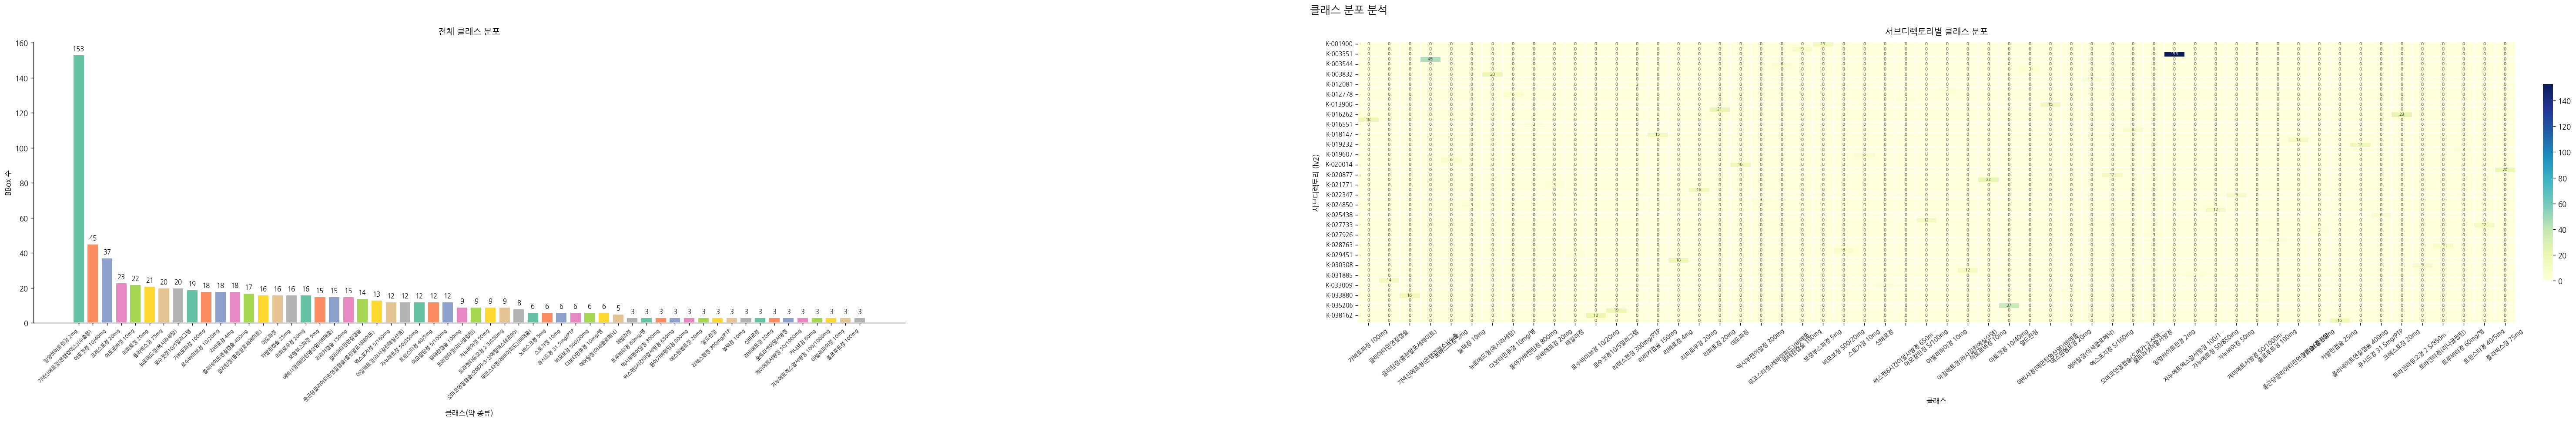

💾 저장: /content/drive/MyDrive/pill_detection/eda_outputs/eda_01_class_dist.png


In [22]:
# ★ 5-1. 클래스 분포 + 서브디렉토리별 히트맵
# [수정] figsize 확대, x축 레이블 자동 각도 조정, 히트맵 폰트 동적 크기 설정
n_classes = len(class_counts)

# 클래스 수에 따라 그림 너비 동적 조정
fig_w = max(18, n_classes * 1.2)
fig   = plt.figure(figsize=(fig_w, 7))
gs    = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], figure=fig)
fig.suptitle('클래스 분포 분석', fontsize=15, fontweight='bold')
plt.subplots_adjust(wspace=0.4, top=0.88)

# ── 전체 클래스 분포 바차트 ──────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
colors = sns.color_palette('Set2', n_classes)
bars   = ax0.bar(range(n_classes), class_counts.values,
                 color=colors, edgecolor='white', linewidth=1.2)
ax0.bar_label(bars, fmt='%d', padding=4, fontsize=9)

# x축 레이블: 클래스 수 많을수록 더 세게 회전
rot = 45 if n_classes > 8 else (30 if n_classes > 4 else 0)
fs  = max(7, 11 - n_classes // 3)  # 클래스 수 많으면 폰트 축소
ax0.set_xticks(range(n_classes))
ax0.set_xticklabels(class_counts.index, rotation=rot,
                     ha='right' if rot > 0 else 'center', fontsize=fs)
ax0.set_title('전체 클래스 분포', fontsize=12, pad=10)
ax0.set_xlabel('클래스(약 종류)', labelpad=10)
ax0.set_ylabel('BBox 수')
ax0.spines[['top', 'right']].set_visible(False)

# ── 서브디렉토리별 클래스 히트맵 ─────────────────────────────────
ax1 = fig.add_subplot(gs[1])
if not pivot_lv2.empty:
    hm       = pivot_lv2.copy()
    # 레이블 길이 제한 (겹침 방지)
    hm.index   = [str(i)[:20] + ('…' if len(str(i)) > 20 else '') for i in hm.index]
    hm.columns = [str(c)[:16] + ('…' if len(str(c)) > 16 else '') for c in hm.columns]
    n_rows  = len(hm)
    ann_fs  = max(6, min(10, 90 // max(n_rows * n_classes, 1)))
    sns.heatmap(
        hm, annot=True, fmt='d', cmap='YlGnBu',
        linewidths=0.4, ax=ax1,
        annot_kws={'size': ann_fs},
        cbar_kws={'shrink': 0.7, 'pad': 0.02}
    )
    ax1.set_title('서브디렉토리별 클래스 분포', fontsize=12, pad=10)
    ax1.set_xlabel('클래스', labelpad=10)
    ax1.set_ylabel('서브디렉토리 (lv2)', labelpad=8)
    ax1.tick_params(axis='x', rotation=40, labelsize=8)
    ax1.tick_params(axis='y', rotation=0,  labelsize=8)

plt.savefig(OUTPUT_DIR / 'eda_01_class_dist.png', bbox_inches='tight')
plt.show()
print(f'💾 저장: {OUTPUT_DIR}/eda_01_class_dist.png')

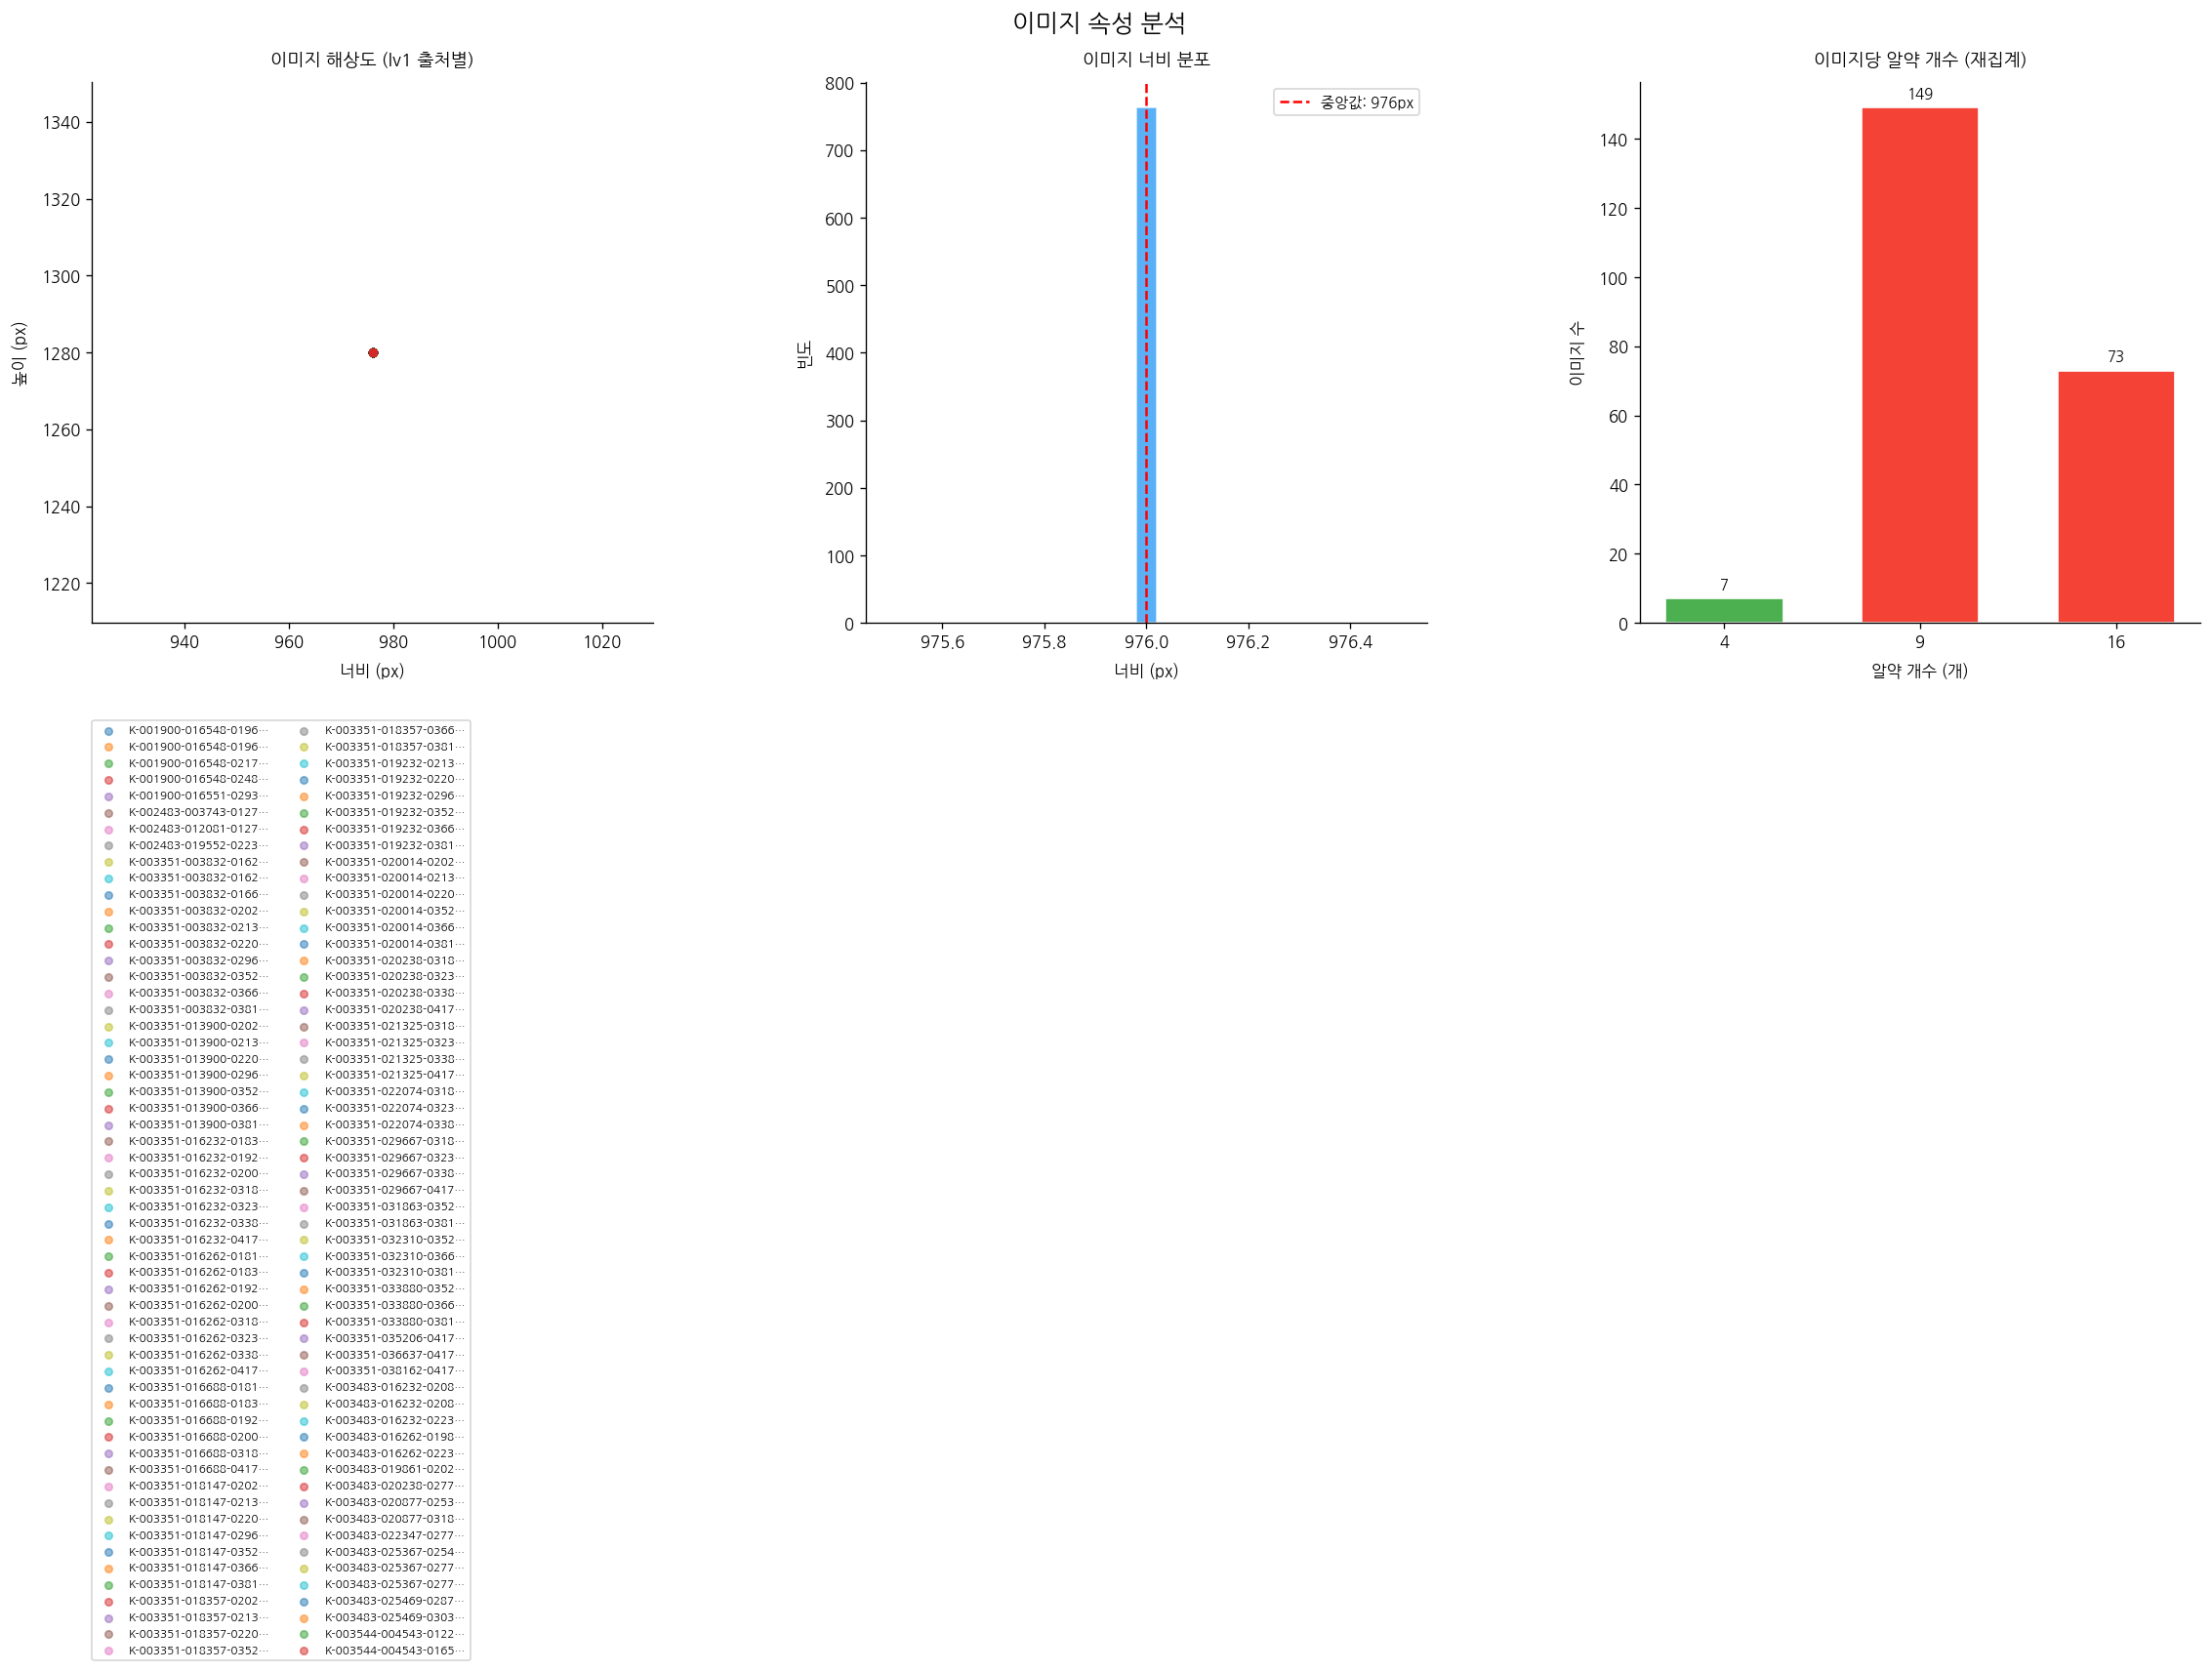

💾 저장: /content/drive/MyDrive/pill_detection/eda_outputs/eda_02_image_props.png


In [23]:
# ★ 5-2. 이미지 속성 분석
# [수정] figsize 확대 (18→20), tight_layout 대신 subplots_adjust로 여백 세밀 조정
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('이미지 속성 분석', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.07, right=0.97, wspace=0.38, top=0.88)

# ── 해상도 산점도 (lv1 출처별) ────────────────────────────────────
ax = axes[0]
lv1_list   = df_img['src_lv1'].unique()
lv1_colors = sns.color_palette('tab10', len(lv1_list))
lv1_cmap   = dict(zip(lv1_list, lv1_colors))
for lv1, grp in df_img.groupby('src_lv1'):
    lbl = str(lv1)[:20] + ('…' if len(str(lv1)) > 20 else '')
    ax.scatter(grp['img_w'], grp['img_h'],
               alpha=0.5, s=20, color=lv1_cmap[lv1], label=lbl)
ax.set_title('이미지 해상도 (lv1 출처별)', fontsize=11, pad=10)
ax.set_xlabel('너비 (px)', labelpad=8)
ax.set_ylabel('높이 (px)', labelpad=8)
# 범례: 항목 많으면 외부 배치
if len(lv1_list) > 5:
    ax.legend(fontsize=7, loc='upper left',
              bbox_to_anchor=(0, -0.18), ncol=2, borderaxespad=0)
else:
    ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── 너비 히스토그램 ───────────────────────────────────────────────
ax = axes[1]
ax.hist(df_img['img_w'].dropna(), bins=25,
        color='#2196F3', alpha=0.75, edgecolor='white')
med_w = df_img['img_w'].median()
ax.axvline(med_w, color='red', linestyle='--', linewidth=1.5,
           label=f'중앙값: {med_w:.0f}px')
ax.set_title('이미지 너비 분포', fontsize=11, pad=10)
ax.set_xlabel('너비 (px)', labelpad=8)
ax.set_ylabel('빈도', labelpad=8)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── 알약 개수 분포 (df_grouped 기준) ──────────────────────────────
ax = axes[2]
colors_p = ['#4CAF50' if i <= 4 else '#F44336'
            for i in pill_dist.index]
x_pos = range(len(pill_dist))
bars3 = ax.bar(x_pos, pill_dist.values,
               color=colors_p, edgecolor='white', width=0.6)
ax.bar_label(bars3, fmt='%d', padding=4, fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(k) for k in pill_dist.index], fontsize=10)
ax.set_title('이미지당 알약 개수 (재집계)', fontsize=11, pad=10)
ax.set_xlabel('알약 개수 (개)', labelpad=8)
ax.set_ylabel('이미지 수', labelpad=8)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(OUTPUT_DIR / 'eda_02_image_props.png', bbox_inches='tight')
plt.show()
print(f'💾 저장: {OUTPUT_DIR}/eda_02_image_props.png')

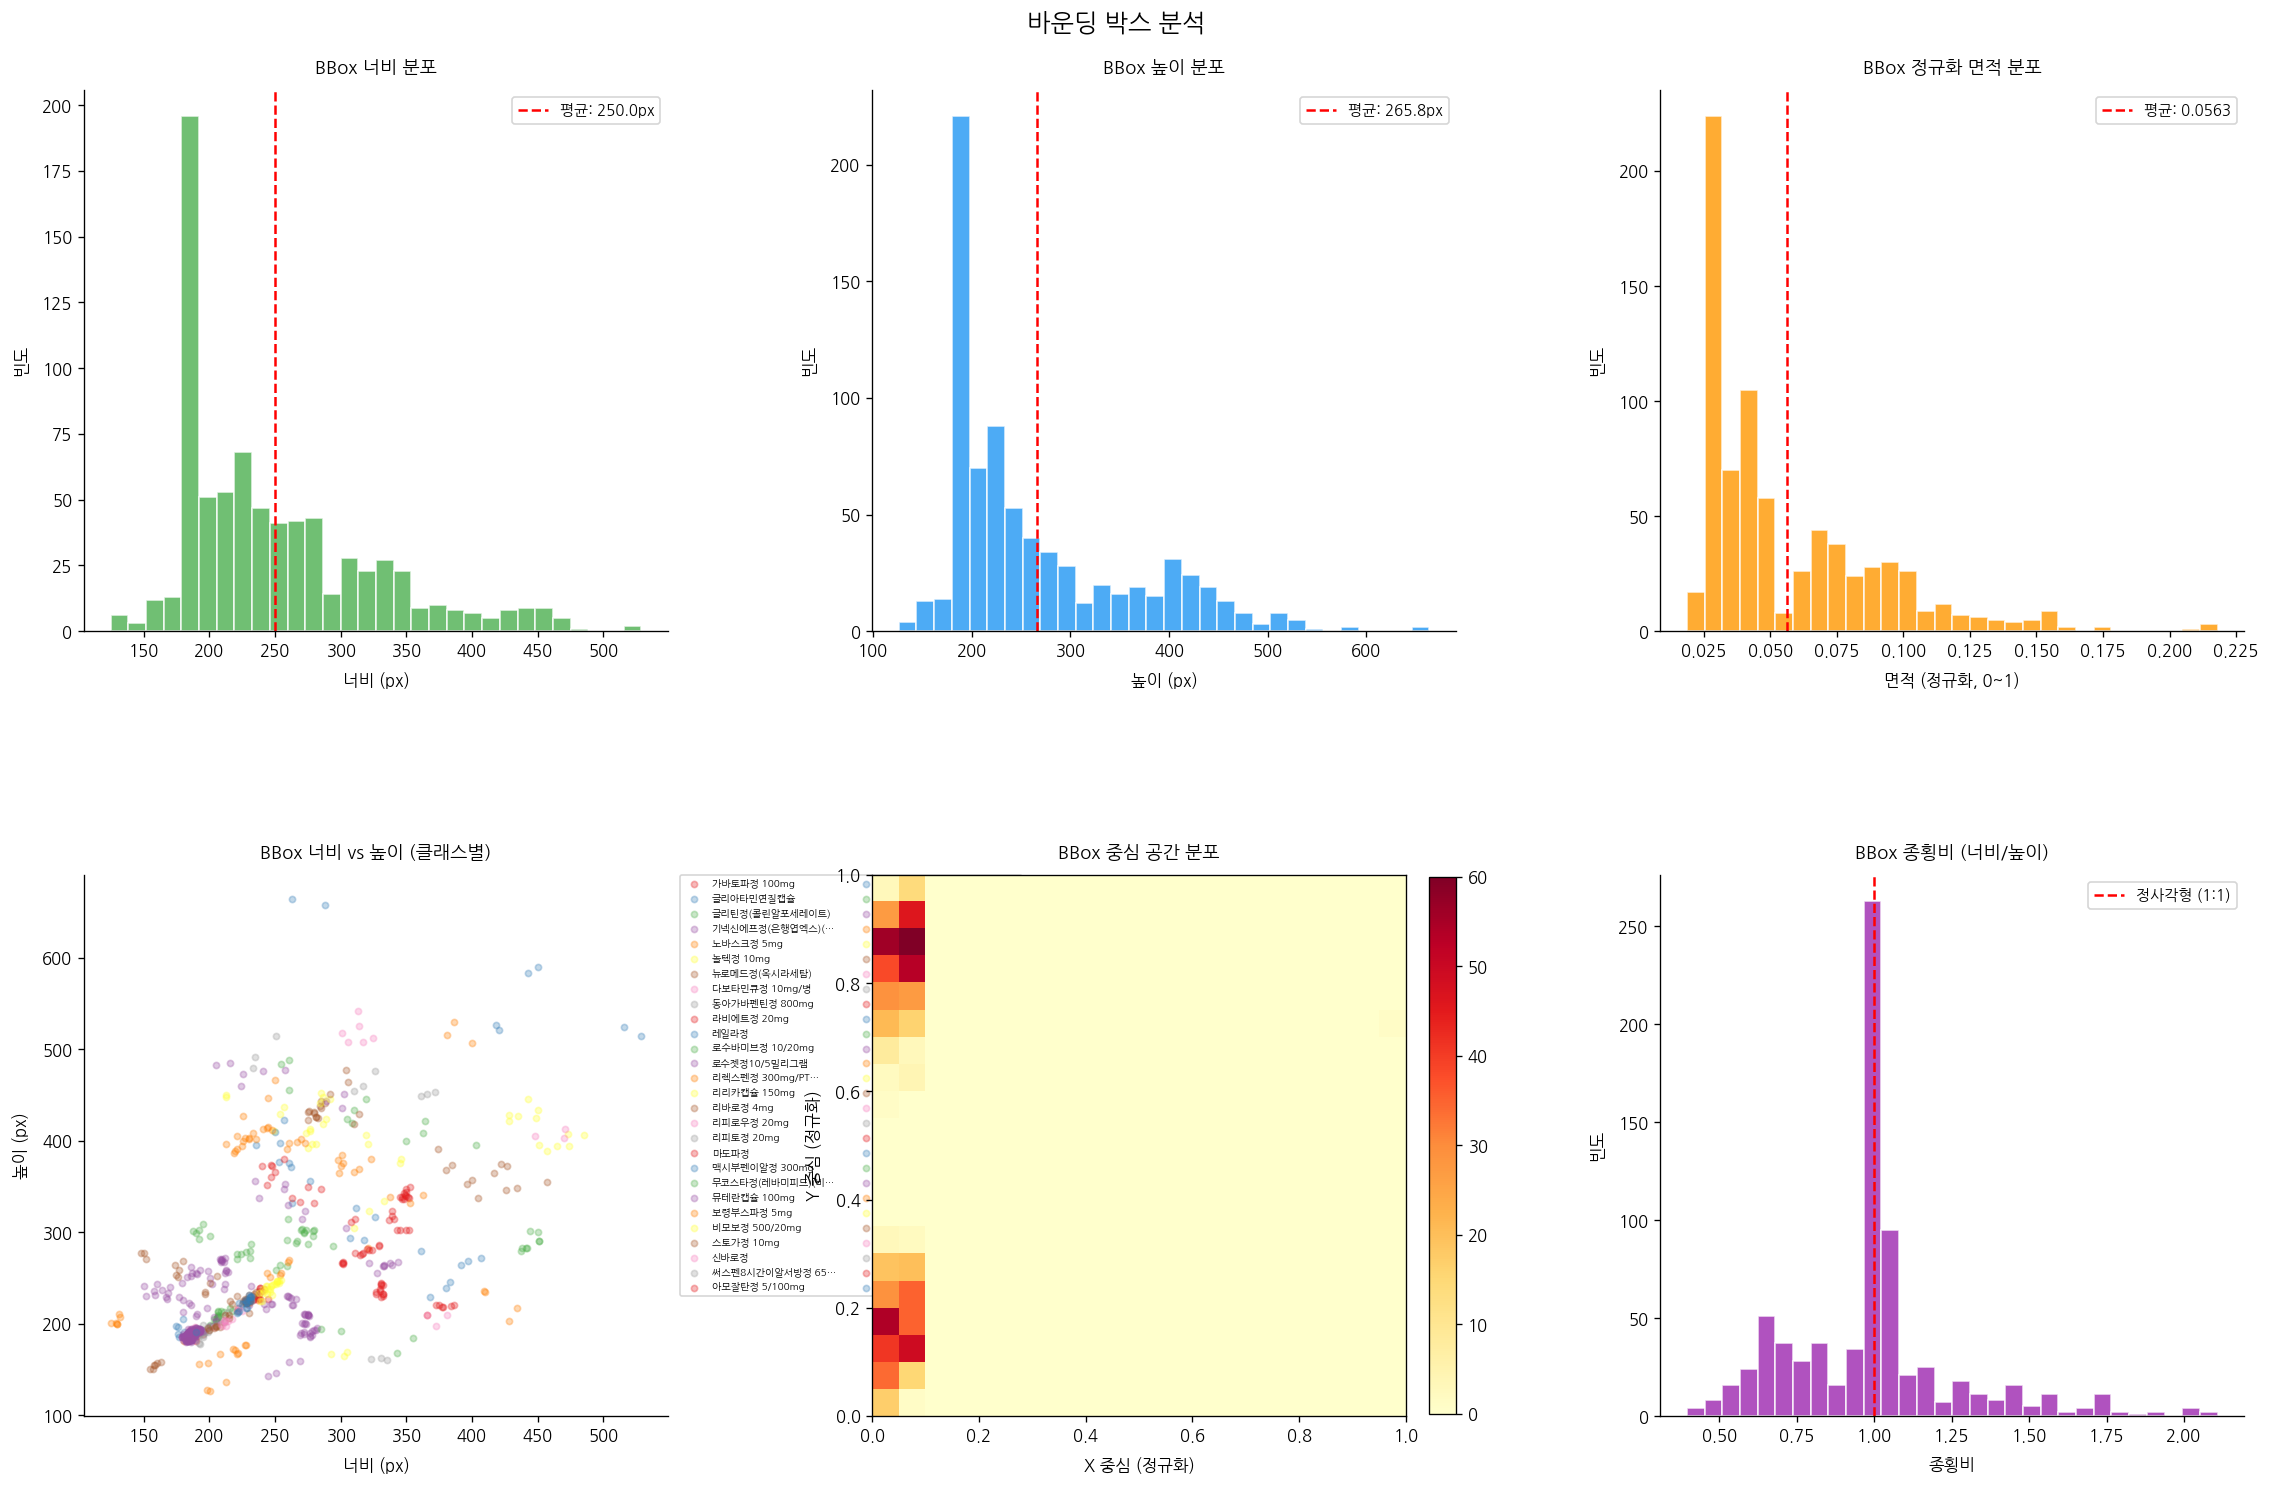

💾 저장: /content/drive/MyDrive/pill_detection/eda_outputs/eda_03_bbox_analysis.png


In [24]:
# ★ 5-3. 바운딩박스 6종 분석
# [수정] figsize (18,11→20,13), hspace/wspace 확대, 각 subplot title pad 추가
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('바운딩 박스 분석', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.07, right=0.97,
                    top=0.93, bottom=0.08,
                    hspace=0.45, wspace=0.35)

# 1) BBox 너비 분포
ax = axes[0, 0]
ax.hist(df_ann['w'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(df_ann['w'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"평균: {df_ann['w'].mean():.1f}px")
ax.set_title('BBox 너비 분포', fontsize=11, pad=10)
ax.set_xlabel('너비 (px)', labelpad=8)
ax.set_ylabel('빈도', labelpad=8)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# 2) BBox 높이 분포
ax = axes[0, 1]
ax.hist(df_ann['h'], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(df_ann['h'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"평균: {df_ann['h'].mean():.1f}px")
ax.set_title('BBox 높이 분포', fontsize=11, pad=10)
ax.set_xlabel('높이 (px)', labelpad=8)
ax.set_ylabel('빈도', labelpad=8)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# 3) 정규화 면적 분포
ax = axes[0, 2]
ax.hist(df_ann['area_norm'], bins=30, color='#FF9800', edgecolor='white', alpha=0.8)
ax.axvline(df_ann['area_norm'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"평균: {df_ann['area_norm'].mean():.4f}")
ax.set_title('BBox 정규화 면적 분포', fontsize=11, pad=10)
ax.set_xlabel('면적 (정규화, 0~1)', labelpad=8)
ax.set_ylabel('빈도', labelpad=8)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# 4) 너비 vs 높이 산점도 (클래스별)
ax = axes[1, 0]
cat_ids = sorted(df_ann['category_id'].unique())
pal     = sns.color_palette('Set1', len(cat_ids))
c_color = {c: pal[i] for i, c in enumerate(cat_ids)}
for cid, grp in df_ann.groupby('category_id'):
    lbl = grp['class_name'].iloc[0]
    lbl_s = lbl[:14] + ('…' if len(lbl) > 14 else '')  # 레이블 길이 제한
    ax.scatter(grp['w'], grp['h'], alpha=0.3, s=14,
               color=c_color[cid], label=lbl_s)
ax.set_title('BBox 너비 vs 높이 (클래스별)', fontsize=11, pad=10)
ax.set_xlabel('너비 (px)', labelpad=8)
ax.set_ylabel('높이 (px)', labelpad=8)
# 클래스 많으면 범례를 축 외부에 배치
if len(cat_ids) > 8:
    ax.legend(fontsize=6, ncol=2,
              bbox_to_anchor=(1.02, 1), loc='upper left',
              borderaxespad=0)
else:
    ax.legend(fontsize=7)
ax.spines[['top', 'right']].set_visible(False)

# 5) BBox 중심 공간 분포 히트맵
ax = axes[1, 1]
hm, xe, ye = np.histogram2d(
    df_ann['cx_norm'].dropna(),
    df_ann['cy_norm'].dropna(), bins=20)
im = ax.imshow(hm.T, origin='lower', aspect='auto',
               extent=[0, 1, 0, 1], cmap='YlOrRd')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('BBox 중심 공간 분포', fontsize=11, pad=10)
ax.set_xlabel('X 중심 (정규화)', labelpad=8)
ax.set_ylabel('Y 중심 (정규화)', labelpad=8)

# 6) BBox 종횡비 분포
ax = axes[1, 2]
valid_ar = df_ann['aspect_ratio'].dropna().clip(0.2, 5)
ax.hist(valid_ar, bins=30, color='#9C27B0', edgecolor='white', alpha=0.8)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5,
           label='정사각형 (1:1)')
ax.set_title('BBox 종횡비 (너비/높이)', fontsize=11, pad=10)
ax.set_xlabel('종횡비', labelpad=8)
ax.set_ylabel('빈도', labelpad=8)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(OUTPUT_DIR / 'eda_03_bbox_analysis.png', bbox_inches='tight')
plt.show()
print(f'💾 저장: {OUTPUT_DIR}/eda_03_bbox_analysis.png')

In [25]:
# ★ 5-4. 샘플 이미지 BBox 오버레이 (df_grouped 기반)
# [수정] df_grouped 가 비어 있는 문제 해결
#        → STEP 3-4에서 file_name 기준 재집계로 df_grouped 를 정상 생성하므로
#           조건 분기 없이 바로 실행 가능
def visualize_annotations(df_grouped_in: pd.DataFrame,
                            num_samples: int = 5):
    """
    df_grouped 에서 랜덤 샘플을 뽑아 이미지 + BBox + 클래스명 오버레이 시각화.
    이미지 경로는 df_grouped 의 img_path 컬럼에서 직접 사용.
    """
    # 파일이 실제 존재하는 이미지만 사용
    valid   = df_grouped_in[df_grouped_in['file_exists'] == True]
    if valid.empty:
        print('⚠️  표시할 수 있는 이미지가 없습니다.')
        return

    samples = valid.sample(n=min(num_samples, len(valid)), random_state=42)

    for _, row in samples.iterrows():
        img_path = Path(row['img_path'])
        if not img_path.exists():
            print(f'  이미지 없음: {img_path.name}')
            continue

        # cv2 로 이미지 로드 후 RGB 변환
        image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(figsize=(9, 9))
        ax.imshow(image)

        # BBox 오버레이
        for bbox, drug_name, cat_id in zip(
                row['bbox'], row['drug_name'], row['category_id']):
            x, y, w, h = bbox
            ax.add_patch(plt.Rectangle(
                (x, y), w, h, linewidth=2,
                edgecolor='red', facecolor='none'))
            # 클래스명 + ID 텍스트 (배경 박스 포함)
            ax.text(x, y - 6, f'{drug_name} (ID:{cat_id})',
                    color='red', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.75, pad=2))

        ax.set_title(
            f'파일: {Path(row["file_name"]).name}  |  알약 {row["n_pills"]}개',
            fontsize=10, pad=8)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# df_grouped 가 정상적으로 채워졌으면 바로 실행 (조건 분기 불필요)
visualize_annotations(df_grouped, num_samples=5)

Output hidden; open in https://colab.research.google.com to view.

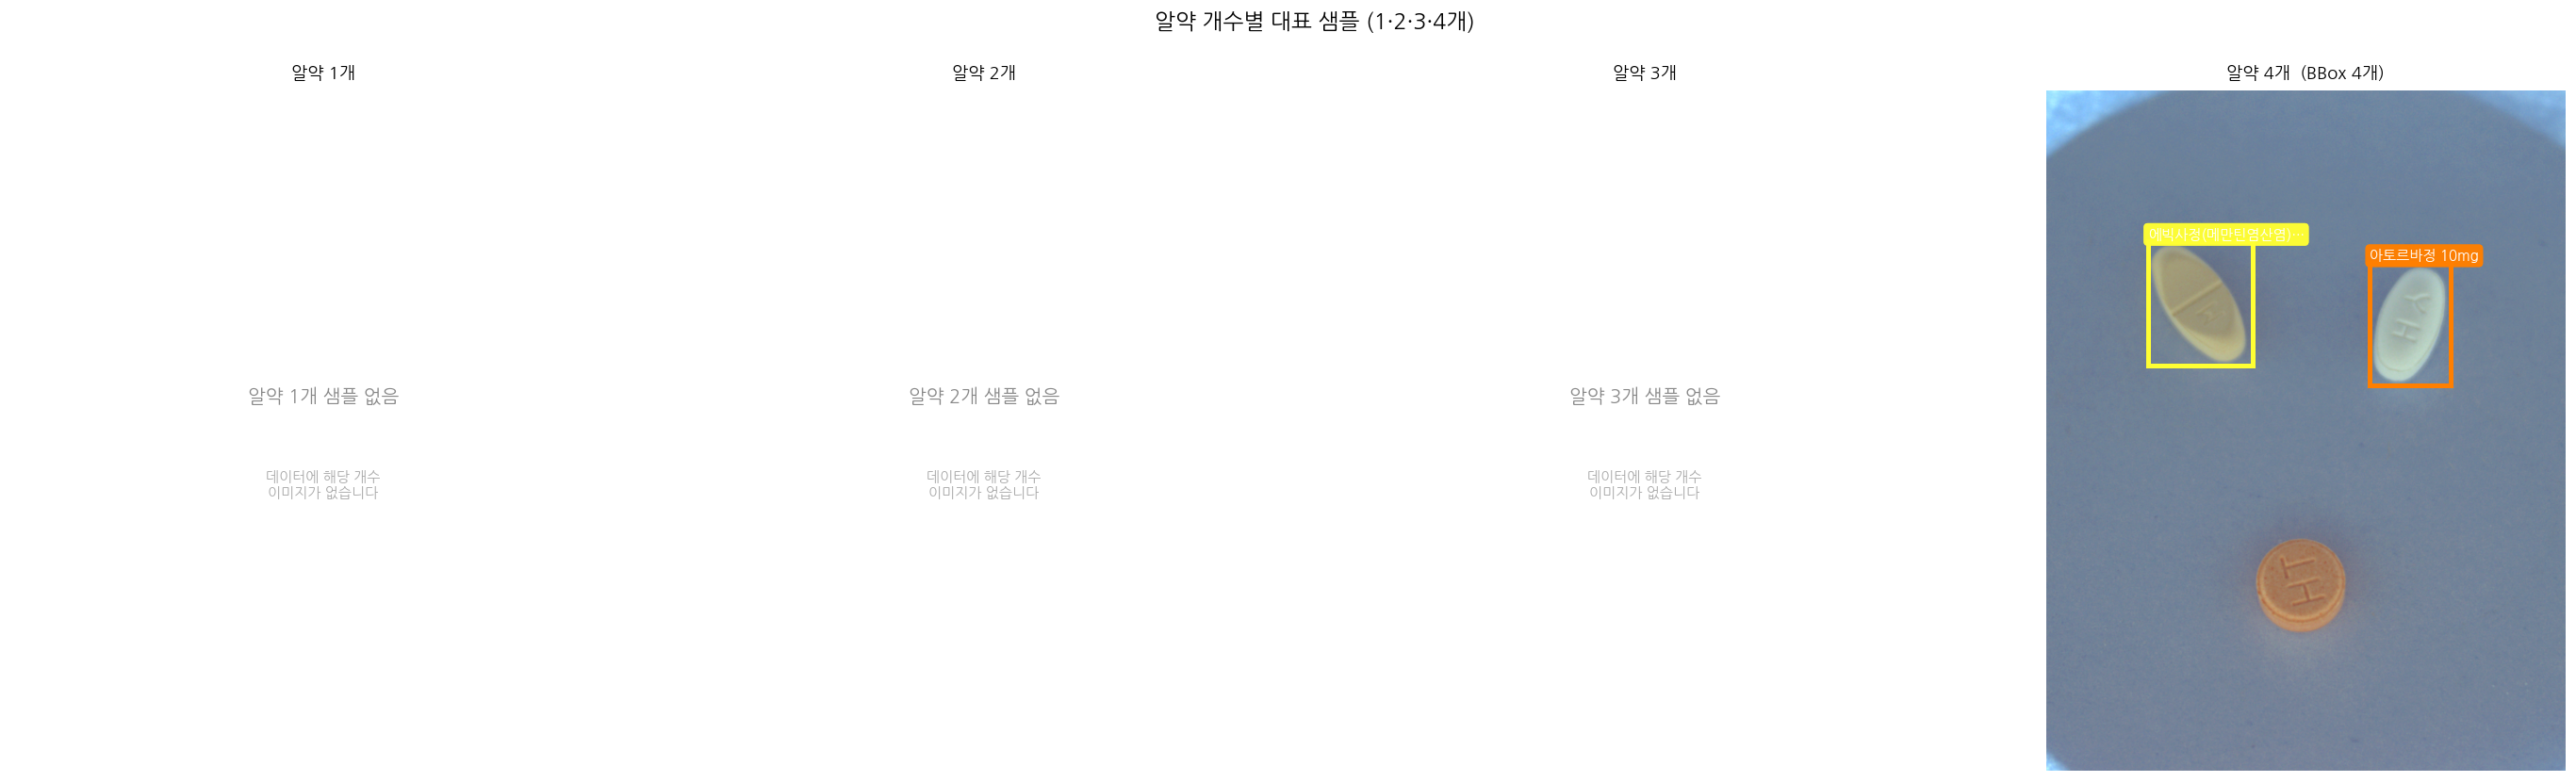

💾 저장: /content/drive/MyDrive/pill_detection/eda_outputs/eda_04_by_count.png


In [26]:
# ★ 5-5. 알약 개수별 대표 샘플 (1·2·3·4개)
#
# [수정 사항 — 이전 버전 대비]
# 1) df_grouped 의 n_pills 는 file_name 기준 재집계된 실제 총 알약 수이므로
#    별도의 ann_by_fn 재집계 없이 df_grouped 에서 직접 필터링 가능
# 2) img_path 도 df_grouped 에 포함되어 있으므로 별도 조회 불필요
# 3) figsize 를 (22,6) → (24,7) 로 확대하여 이미지와 라벨이 넉넉하게 표시
# 4) BBox 라벨 폰트 크기·위치를 이미지 크기 비례로 자동 조정

target_counts = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 4, figsize=(24, 7))
fig.suptitle('알약 개수별 대표 샘플 (1·2·3·4개)',
             fontsize=14, fontweight='bold')
plt.subplots_adjust(left=0.02, right=0.98,
                    top=0.88, bottom=0.02, wspace=0.06)

# 클래스별 색상 팔레트 구성
palette = plt.cm.get_cmap('Set1', max(len(cat_ids), 1))
c_color = {
    c: palette(i / max(len(cat_ids) - 1, 1))
    for i, c in enumerate(cat_ids)
}

for ax, n in zip(axes, target_counts):
    # df_grouped 에서 해당 알약 개수 + 파일 존재 조건 필터
    sub = df_grouped[
        (df_grouped['n_pills'] == n) &
        (df_grouped['file_exists'] == True)
    ]

    # 해당 개수의 샘플이 없는 경우 안내 메시지 표시
    if sub.empty:
        ax.set_facecolor('#f8f8f8')
        ax.text(0.5, 0.55,
                f'알약 {n}개 샘플 없음',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#888888', fontweight='bold')
        ax.text(0.5, 0.42,
                '데이터에 해당 개수\n이미지가 없습니다',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='#aaaaaa')
        ax.set_title(f'알약 {n}개', fontsize=11, pad=8)
        ax.axis('off')
        continue

    # 랜덤 샘플 1장 선택
    row = sub.sample(1, random_state=42).iloc[0]

    # 이미지 로드 (PIL 사용)
    try:
        img = np.array(Image.open(row['img_path']).convert('RGB'))
    except Exception as e:
        ax.text(0.5, 0.5, f'로드 실패\n{Path(row["img_path"]).name}',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.axis('off')
        continue

    ax.imshow(img)

    # 이미지 크기 기반 폰트 크기 자동 조정 (작은 이미지에서 겹침 방지)
    img_h, img_w = img.shape[:2]
    lbl_fs = max(7, min(10, img_w // 100))
    lw     = max(1.5, min(3.0, img_w / 300))  # 선 두께도 비례 조정

    # df_grouped 의 bbox/drug_name/category_id 리스트를 직접 순회
    for bbox, drug_name, cat_id in zip(
            row['bbox'], row['drug_name'], row['category_id']):
        x, y, w, h = bbox
        color = c_color.get(cat_id, 'lime')
        ax.add_patch(patches.Rectangle(
            (x, y), w, h,
            linewidth=lw, edgecolor=color, facecolor='none'))
        # 클래스명 텍스트 (12자 초과 시 말줄임)
        lbl = str(drug_name)[:12] + ('…' if len(str(drug_name)) > 12 else '')
        ax.text(x, max(y - 5, 0), lbl,
                color='white', fontsize=lbl_fs,
                bbox=dict(facecolor=color, alpha=0.85,
                          pad=1.5, edgecolor='none',
                          boxstyle='round,pad=0.3'))

    ax.set_title(
        f'알약 {n}개  (BBox {len(row["bbox"])}개)',
        fontsize=11, pad=8)
    ax.axis('off')

plt.savefig(OUTPUT_DIR / 'eda_04_by_count.png', bbox_inches='tight')
plt.show()
print(f'💾 저장: {OUTPUT_DIR}/eda_04_by_count.png')

---
## STEP 6. 데이터 무결성 검사

> 8가지 항목을 자동으로 검사합니다.  
> 헬스케어 도메인에서 어노테이션 오류는 **의료 안전에 직결**되므로 필수 수행 단계입니다.
>
> | 항목 | 내용 | 수준 |
> |---|---|---|
> | 1 | 이미지 파일 누락 | 🚨 즉시 조치 |
> | 2 | 어노테이션 없는 이미지 | ⚠️ 확인 권장 |
> | 3 | JSON 간 중복 file_name | ℹ️ 이 데이터셋 정상 구조 |
> | 4 | n_pills ≠ n_bbox 불일치 | 🚨 즉시 조치 |
> | 5 | iscrowd=1 어노테이션 | ⚠️ 확인 권장 |
> | 6 | 좌표 이상 BBox | 🚨 즉시 조치 |
> | 7 | 극소 BBox (10px 이하) | ⚠️ 확인 권장 |
> | 8 | 중복 어노테이션 | ⚠️ 확인 권장 |

In [27]:
print('=' * 65)
print('🔍 데이터 무결성 검사 결과')
print('=' * 65)

issues    = []  # 즉시 조치 필요
warnings_ = []  # 확인 권장

# [1] 이미지 파일 누락
missing = df_img[~df_img['file_exists']]
print(f'\n[1] 이미지 파일 누락 (Drive 경로 없음): {len(missing)}개')
if len(missing) > 0:
    issues.append(f'파일 누락 {len(missing)}개')
    print('    조치 → STEP 1-1 collect_png_files() 재실행')
    display(missing[['file_name', 'src_json']].head(5))

# [2] 어노테이션 없는 이미지
no_ann = df_img[df_img['n_pills'] == 0]
print(f'\n[2] 어노테이션 없는 이미지 (n_pills=0): {len(no_ann)}개')
if len(no_ann) > 0:
    warnings_.append(f'빈 어노테이션 {len(no_ann)}개')
    print('    조치 → 학습 제외 또는 background 클래스 활용')

# [3] JSON 간 중복 file_name (이 데이터셋의 정상 구조)
dup_fn = df_img[df_img.duplicated(subset='file_name', keep=False)]
print(f'\n[3] JSON 간 중복 file_name: {len(dup_fn)}개')
if len(dup_fn) > 0:
    print('    ℹ️  이 데이터셋은 동일 PNG가 여러 JSON에 등록된 정상 구조입니다.')
    print('    → STEP 3-4 의 file_name 기준 재집계로 정상 처리됩니다.')

# [4] n_pills ≠ n_bbox 불일치 (df_grouped 기준)
mismatch = df_grouped[
    df_grouped['n_pills'] != df_grouped['bbox'].apply(len)
]
print(f'\n[4] n_pills ≠ bbox 개수 불일치 (df_grouped): {len(mismatch)}개')
if len(mismatch) > 0:
    issues.append(f'개수 불일치 {len(mismatch)}개')
    display(mismatch[['file_name', 'n_pills']].head(5))

# [5] iscrowd=1 어노테이션
crowd = df_ann[df_ann['iscrowd'] == 1]
print(f'\n[5] iscrowd=1 어노테이션: {len(crowd)}개')
if len(crowd) > 0:
    warnings_.append(f'iscrowd {len(crowd)}개')
    print('    조치 → 학습 전 df_ann[df_ann.iscrowd==0] 필터')

# [6] 좌표 이상 BBox (음수 또는 이미지 크기 초과)
bad_coord = df_ann[
    (df_ann['x'] < 0) | (df_ann['y'] < 0) |
    (df_ann['w'] <= 0) | (df_ann['h'] <= 0) |
    (df_ann['x'] + df_ann['w'] > df_ann['img_w']) |
    (df_ann['y'] + df_ann['h'] > df_ann['img_h'])
]
print(f'\n[6] 좌표 이상 BBox (음수·범위 초과): {len(bad_coord)}개')
if len(bad_coord) > 0:
    issues.append(f'좌표 이상 {len(bad_coord)}개')
    print('    조치 → np.clip 으로 이미지 경계 내 클리핑')

# [7] 극소 BBox (10px 이하)
tiny = df_ann[(df_ann['w'] < 10) | (df_ann['h'] < 10)]
print(f'\n[7] 극소 BBox (w 또는 h < 10px): {len(tiny)}개')
if len(tiny) > 0:
    warnings_.append(f'극소 BBox {len(tiny)}개')
    print('    조치 → 육안 확인 후 레이블 오류이면 제거')

# [8] 중복 어노테이션
dup_ann = df_ann.duplicated(
    subset=['image_id', 'x', 'y', 'w', 'h', 'category_id'])
print(f'\n[8] 중복 어노테이션 (동일 image+bbox+class): {dup_ann.sum()}개')
if dup_ann.sum() > 0:
    warnings_.append(f'중복 어노테이션 {dup_ann.sum()}개')
    print('    조치 → df_ann.drop_duplicates() 적용')

# ── 최종 요약 ────────────────────────────────────────────────────
print('\n' + '=' * 65)
if issues:
    print(f'🚨 즉시 조치 필요 ({len(issues)}건): {", ".join(issues)}')
if warnings_:
    print(f'⚠️  확인 권장 ({len(warnings_)}건): {", ".join(warnings_)}')
if not issues and not warnings_:
    print('✅ 모든 항목 통과 — 데이터 품질 양호')
print('=' * 65)

🔍 데이터 무결성 검사 결과

[1] 이미지 파일 누락 (Drive 경로 없음): 0개

[2] 어노테이션 없는 이미지 (n_pills=0): 0개

[3] JSON 간 중복 file_name: 763개
    ℹ️  이 데이터셋은 동일 PNG가 여러 JSON에 등록된 정상 구조입니다.
    → STEP 3-4 의 file_name 기준 재집계로 정상 처리됩니다.

[4] n_pills ≠ bbox 개수 불일치 (df_grouped): 0개

[5] iscrowd=1 어노테이션: 0개

[6] 좌표 이상 BBox (음수·범위 초과): 1개
    조치 → np.clip 으로 이미지 경계 내 클리핑

[7] 극소 BBox (w 또는 h < 10px): 0개

[8] 중복 어노테이션 (동일 image+bbox+class): 0개

🚨 즉시 조치 필요 (1건): 좌표 이상 1개


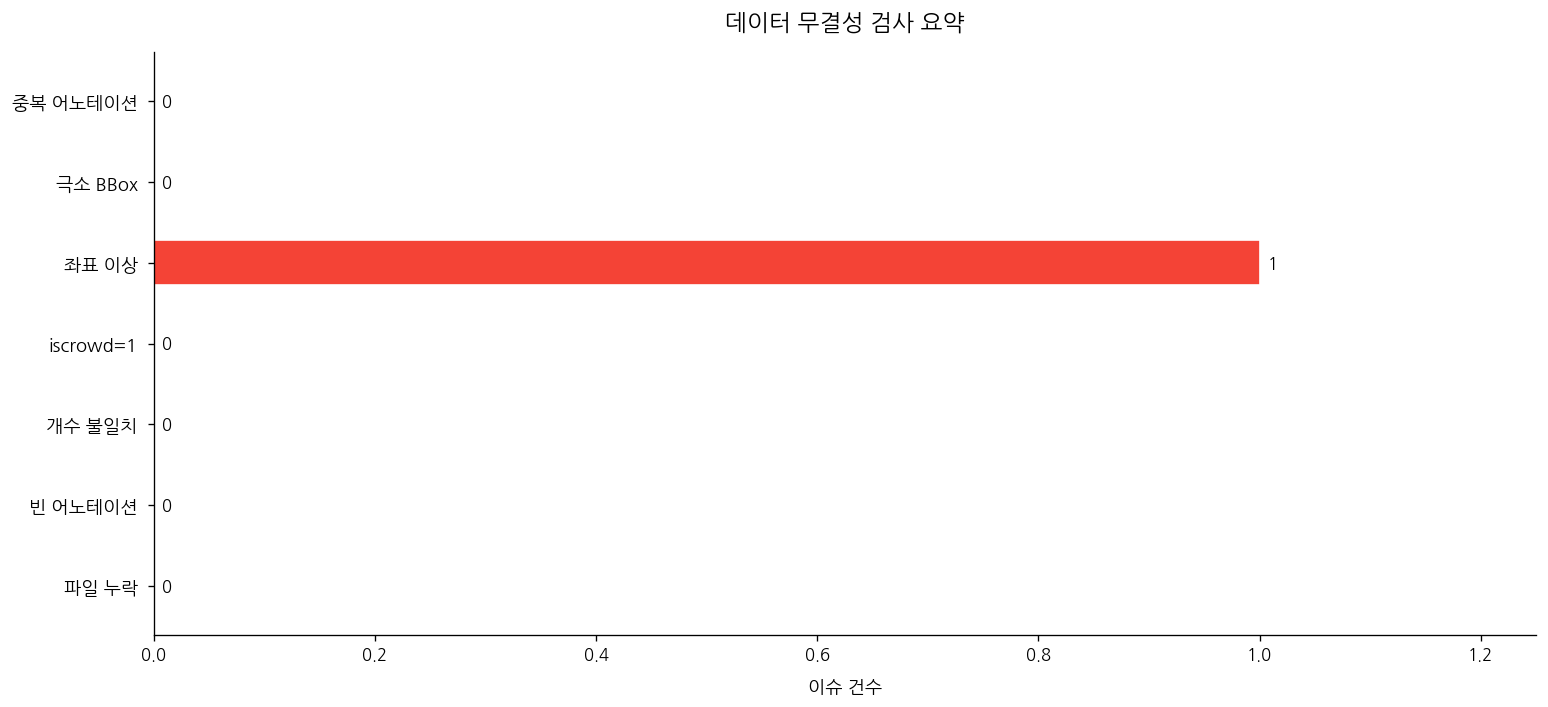


📁 결과 저장 위치: /content/drive/MyDrive/pill_detection/eda_outputs

  ✅  eda_01_class_dist.png                             클래스 분포 + 서브디렉토리 히트맵
  ✅  eda_02_image_props.png                            이미지 속성 + 알약 개수 분포
  ✅  eda_03_bbox_analysis.png                          BBox 6종 분석
  ✅  eda_04_by_count.png                               알약 개수별 대표 샘플 (1·2·3·4개)
  ✅  eda_05_integrity_check.png                        무결성 검사 요약
  ✅  category_mapping.json                             category_id 0-based 매핑
  ✅  category_name_mapping.json                        id → drug_name 매핑
  ✅  df_master.csv                                     전체 마스터 DataFrame
  ✅  df_usable.csv                                     학습용 필터링 DataFrame
  ✅  df_grouped.csv                                    이미지 단위 그룹화 DataFrame


In [28]:
# ★ 무결성 검사 요약 차트
# [수정] figsize 확대, x축 여유 공간 추가, 막대 간격(height) 조정
check_items = [
    ('파일 누락',         len(df_img[~df_img['file_exists']])),
    ('빈 어노테이션',     len(df_img[df_img['n_pills'] == 0])),
    ('개수 불일치',       len(mismatch)),
    ('iscrowd=1',         len(crowd)),
    ('좌표 이상',         len(bad_coord)),
    ('극소 BBox',         len(tiny)),
    ('중복 어노테이션',   int(dup_ann.sum())),
]
labels   = [c[0] for c in check_items]
values   = [c[1] for c in check_items]
colors_c = ['#F44336' if v > 0 else '#4CAF50' for v in values]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(labels, values, color=colors_c,
               edgecolor='white', height=0.55)
ax.bar_label(bars, fmt='%d', padding=5, fontsize=10)

ax.set_xlabel('이슈 건수', labelpad=10, fontsize=11)
ax.set_title('데이터 무결성 검사 요약',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='y', labelsize=11, pad=6)
ax.tick_params(axis='x', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
# x축 최댓값에 여유 공간 추가 (레이블 겹침 방지)
ax.set_xlim(0, max(values + [1]) * 1.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_05_integrity_check.png', bbox_inches='tight')
plt.show()

# ── 최종 결과물 목록 ──────────────────────────────────────────────
print(f'\n📁 결과 저장 위치: {OUTPUT_DIR}\n')
for fn, desc in [
    ('eda_01_class_dist.png',      '클래스 분포 + 서브디렉토리 히트맵'),
    ('eda_02_image_props.png',     '이미지 속성 + 알약 개수 분포'),
    ('eda_03_bbox_analysis.png',   'BBox 6종 분석'),
    ('eda_04_by_count.png',        '알약 개수별 대표 샘플 (1·2·3·4개)'),
    ('eda_05_integrity_check.png', '무결성 검사 요약'),
    ('category_mapping.json',      'category_id 0-based 매핑'),
    ('category_name_mapping.json', 'id → drug_name 매핑'),
    ('df_master.csv',              '전체 마스터 DataFrame'),
    ('df_usable.csv',              '학습용 필터링 DataFrame'),
    ('df_grouped.csv',             '이미지 단위 그룹화 DataFrame'),
]:
    mark = '✅' if (OUTPUT_DIR/fn).exists() else '⏳'
    print(f'  {mark}  {fn:<48s}  {desc}')